# PF — Page features: when an engine cites a page, which writing traits predict better treatment?

RQ1–RQ3 measured **where** engines surface sources and **how faithfully** they represent them. This notebook asks the follow-up question a GEO practitioner actually acts on: *among pages that got cited, which on-page writing traits co-occur with (a) earlier citation slots, (b) being clearly supported by the answer text, and (c) being re-cited run after run?*

**Data.** 47,852 citation events with fetched page text (of 58,851 total; the rest failed to fetch), built from the gold star schema + the 3.5 GB silver sources text by `scripts/build_page_features.py`. All entailment outcomes use the **cleaned** convention: artifact sentences are excluded and the RQ3 Q13 bands apply verbatim (clearly supported = entail score ≥ 0.50). Page features are winsorized (1/99) and z-standardized pooled across engines, so coefficients are comparable: *effect per +1 SD* (binary traits: effect of 0→1).

**Models.** Per engine: logit for a first-3 citation slot, OLS for clearly-supported share, OLS for re-citation rate across the k = 8 repeats — each with query-topic, intent and source-type fixed effects plus response citation count, and SEs clustered by pay-level domain (estimators are hand-rolled numpy/scipy — the pinned env has no statsmodels — and self-validated in the preamble). p-values are BH-FDR corrected within each model.

**Read this before acting on it.** Only *cited* pages are observable, so every estimate is conditional on having been cited at least once — this says "among cited pages, the better-treated ones look like X", not "X gets you cited". Associations are covariate-adjusted but not causal. Gemini appears in the event-level models (its real source domain is preserved) but not in the page-level stickiness model — its citation URLs are per-response redirect tokens, so page identity across runs is unobservable.

Shared style, palette, data and validators live in the first code cell; models are fitted once in the second; every figure below is one compact cell followed by a plain-English **Key analysis**.

In [1]:
# === PF shared preamble: style (Visual_Style_Guide §13 + §5), data, estimators, validators ===
import os, logging, warnings, numpy as np, pandas as pd
import matplotlib.pyplot as plt, matplotlib as mpl
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
from scipy import stats
warnings.filterwarnings("ignore"); logging.getLogger("matplotlib.font_manager").setLevel(logging.ERROR)

# §13 matplotlib global configuration block (verbatim)
mpl.rcParams["font.family"] = "sans-serif"; mpl.rcParams["font.sans-serif"] = ["Calibri", "DejaVu Sans", "Arial"]; mpl.rcParams["font.size"] = 11
mpl.rcParams["axes.spines.top"] = False; mpl.rcParams["axes.spines.right"] = False
mpl.rcParams["axes.edgecolor"] = "#374151"; mpl.rcParams["axes.linewidth"] = 0.8; mpl.rcParams["axes.labelpad"] = 10
mpl.rcParams["axes.titlesize"] = 14; mpl.rcParams["axes.titleweight"] = "bold"; mpl.rcParams["axes.labelsize"] = 12
mpl.rcParams["axes.grid"] = True; mpl.rcParams["axes.grid.axis"] = "y"
mpl.rcParams["grid.color"] = "#E5E7EB"; mpl.rcParams["grid.linewidth"] = 0.5; mpl.rcParams["grid.linestyle"] = "--"; mpl.rcParams["axes.axisbelow"] = True
mpl.rcParams["xtick.direction"] = "out"; mpl.rcParams["ytick.direction"] = "out"
mpl.rcParams["xtick.major.size"] = 4; mpl.rcParams["ytick.major.size"] = 4; mpl.rcParams["xtick.labelsize"] = 11; mpl.rcParams["ytick.labelsize"] = 11
mpl.rcParams["legend.frameon"] = False; mpl.rcParams["legend.fontsize"] = 11
mpl.rcParams["figure.figsize"] = (7, 4.5); mpl.rcParams["figure.dpi"] = 300
mpl.rcParams["savefig.dpi"] = 300; mpl.rcParams["savefig.bbox"] = "tight"; mpl.rcParams["savefig.pad_inches"] = 0.15

ENGINE_COLOURS = {"chatgpt": "#2CA058", "claude": "#D97706", "gemini": "#2563EB", "kimi": "#7C3AED", "perplexity": "#0891B2"}
ENGINE_ORDER = ["chatgpt", "claude", "gemini", "kimi", "perplexity"]
ENGINE_LABELS = {"chatgpt": "ChatGPT", "claude": "Claude", "gemini": "Gemini", "kimi": "Kimi", "perplexity": "Perplexity"}
ENGINE_MARKERS = {"chatgpt": "o", "claude": "s", "gemini": "^", "kimi": "D", "perplexity": "X"}
COLOUR_PRIMARY = "#1F4E79"; COLOUR_NEUTRAL = "#6B7280"; COLOUR_REFERENCE = "#DC2626"; COLOUR_GRID = "#E5E7EB"
CMAP_DIVERGENT = LinearSegmentedColormap.from_list("teal_divergent", ["#B45309", "#F3F4F6", "#1F4E79"])

def apply_style(ax):
    ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)
    ax.spines["left"].set_color("#374151"); ax.spines["bottom"].set_color("#374151")
    ax.spines["left"].set_linewidth(0.8); ax.spines["bottom"].set_linewidth(0.8)
    ax.yaxis.grid(True, color="#E5E7EB", linewidth=0.5, linestyle="--"); ax.set_axisbelow(True)
    ax.tick_params(direction="out", length=4, labelsize=11)

ROOT = next(p for p in [os.getcwd()] + [os.path.abspath(os.path.join(os.getcwd(), *[".."] * i)) for i in (1, 2, 3)]
            if os.path.exists(os.path.join(p, "thesis_config.py")))
PF_DIR = os.path.join(ROOT, "analysis/page_features"); FIG_DIR = os.path.join(ROOT, "figures/scaleup/pagefeat")
os.makedirs(FIG_DIR, exist_ok=True)

def savefig(fig, name):
    for ext in ("png", "pdf"): fig.savefig(os.path.join(FIG_DIR, f"{name}.{ext}"))
    print(f"saved {name}")

M   = pd.read_parquet(os.path.join(PF_DIR, "model_frame_events.parquet"))         # event level, has_text only
ST  = pd.read_parquet(os.path.join(PF_DIR, "model_frame_sticky.parquet"))         # (url, engine, query); no gemini
STD = pd.read_parquet(os.path.join(PF_DIR, "model_frame_sticky_domain.parquet"))  # (pld, engine, query); all engines

CONT = ["log1p_n_words", "flesch_c", "avg_word_len", "digits_per_100w", "dates_per_100w", "lead_num_token_share",
        "caps_mid_share", "ttr_1000", "short_line_share", "bullet_line_share", "newlines_per_100w",
        "question_lines_per_100", "nav_noise_share", "title_len_words", "title_query_jaccard", "lead_query_coverage"]
BIN = ["has_recent_year", "lead_has_year", "title_is_question", "title_has_number", "title_listicle"]
FEATURES = CONT + BIN
DISP = {"log1p_n_words": "Page length (log words)", "flesch_c": "Flesch reading ease", "avg_word_len": "Avg word length (lexical density)",
        "digits_per_100w": "Digit tokens per 100 words", "dates_per_100w": "Date mentions per 100 words",
        "lead_num_token_share": "Numeric tokens in lead", "caps_mid_share": "Mid-sentence capitals (entity density)",
        "ttr_1000": "Vocabulary diversity (TTR)", "short_line_share": "Short-line share", "bullet_line_share": "Bulleted-line share",
        "newlines_per_100w": "Line breaks per 100 words", "question_lines_per_100": "Question lines per 100",
        "nav_noise_share": "Nav clutter at page top", "title_len_words": "Title length (words)",
        "title_query_jaccard": "Title–query word overlap", "lead_query_coverage": "Query terms covered in lead",
        "has_recent_year": "Mentions a 2024+ year (0→1)", "lead_has_year": "Year in lead (0→1)",
        "title_is_question": "Question-style title (0→1)", "title_has_number": "Number in title (0→1)",
        "title_listicle": "Listicle-style title (0→1)"}

# --- cluster-robust estimators (numpy/scipy only; CR1 Liang–Zeger sandwich) ---
def _cr1(n, k, G): return (G / (G - 1)) * ((n - 1) / (n - k))

def ols_cluster(X, y, clusters):
    X = np.asarray(X, float); y = np.asarray(y, float); n, k = X.shape
    XtX_inv = np.linalg.pinv(X.T @ X); beta = XtX_inv @ (X.T @ y); e = y - X @ beta
    if np.std(y) < 1e-12 or np.max(np.abs(e)) < 1e-10:  # degenerate outcome guard
        return {"beta": np.zeros(k), "se": np.full(k, np.inf), "z": np.zeros(k), "p": np.ones(k), "n": n, "G": len(np.unique(clusters))}
    cl = np.asarray(clusters); meat = np.zeros((k, k))
    for g in np.unique(cl):
        m = cl == g; s = X[m].T @ e[m]; meat += np.outer(s, s)
    G = len(np.unique(cl)); V = XtX_inv @ meat @ XtX_inv * _cr1(n, k, G)
    se = np.sqrt(np.clip(np.diag(V), 0, None)); z = np.divide(beta, se, out=np.zeros_like(beta), where=se > 0)
    return {"beta": beta, "se": se, "z": z, "p": 2 * stats.norm.sf(np.abs(z)), "n": n, "G": G}

def logit_cluster(X, y, clusters, max_iter=100, tol=1e-10, ridge=1e-8):
    X = np.asarray(X, float); y = np.asarray(y, float); n, k = X.shape
    if np.std(y) < 1e-12:
        return {"beta": np.zeros(k), "se": np.full(k, np.inf), "z": np.zeros(k), "p": np.ones(k), "n": n, "G": len(np.unique(clusters))}
    beta = np.zeros(k)
    for _ in range(max_iter):
        p = 1.0 / (1.0 + np.exp(-np.clip(X @ beta, -30, 30))); W = p * (1 - p)
        step = np.linalg.pinv((X * W[:, None]).T @ X + ridge * np.eye(k)) @ (X.T @ (y - p))
        beta = beta + step
        if np.max(np.abs(step)) < tol: break
    p_hat = 1.0 / (1.0 + np.exp(-np.clip(X @ beta, -30, 30))); W = p_hat * (1 - p_hat)
    bread = np.linalg.pinv((X * W[:, None]).T @ X + ridge * np.eye(k)); resid = y - p_hat
    cl = np.asarray(clusters); meat = np.zeros((k, k))
    for g in np.unique(cl):
        m = cl == g; s = X[m].T @ resid[m]; meat += np.outer(s, s)
    G = len(np.unique(cl)); V = bread @ meat @ bread * _cr1(n, k, G)
    se = np.sqrt(np.clip(np.diag(V), 0, None)); z = np.divide(beta, se, out=np.zeros_like(beta), where=se > 0)
    return {"beta": beta, "se": se, "z": z, "p": 2 * stats.norm.sf(np.abs(z)), "n": n, "G": G}

def bh_fdr(pvals):
    p = np.asarray(pvals, float); m = len(p); order = np.argsort(p)
    ranked = p[order] * m / (np.arange(m) + 1); ranked = np.minimum.accumulate(ranked[::-1])[::-1]
    q = np.empty(m); q[order] = np.clip(ranked, 0, 1); return q

def design(df, features):
    cols, names = [np.ones(len(df))], ["const"]
    for f in features: cols.append(df[f].values); names.append(f)
    cols.append(df.log_n_cited.values - df.log_n_cited.mean()); names.append("log_n_cited")
    for cvar in ["qd", "dt", "intent"]:
        d = pd.get_dummies(df[cvar], prefix=cvar, drop_first=True, dtype=float)
        for c in d.columns: cols.append(d[c].values); names.append(c)
    X = np.column_stack(cols)
    keep = [i for i in range(X.shape[1]) if i == 0 or X[:, i].std() > 1e-12]
    return X[:, keep], [names[i] for i in keep]

def forest(res, outcome, engines, scale, xlabel, title, fname, top=10):
    r = res[(res.outcome == outcome) & (res.engine.isin(engines))].copy()
    order = (r.groupby("feature").z.apply(lambda s: s.abs().max()).sort_values(ascending=False).head(top).index.tolist())
    fig, ax = plt.subplots(figsize=(9, 0.62 * len(order) + 2.4))
    offs = np.linspace(0.28, -0.28, len(engines))
    for oi, eng in enumerate(engines):
        d = r[r.engine == eng].set_index("feature").reindex(order)
        y = np.arange(len(order))[::-1] + offs[oi]
        sig = d.q.values < 0.05
        ax.errorbar(d.beta.values * scale, y, xerr=1.96 * d.se.values * scale, fmt="none",
                    ecolor=ENGINE_COLOURS[eng], elinewidth=1.1, capsize=0, alpha=0.85)
        ax.scatter(d.beta.values * scale, y, marker=ENGINE_MARKERS[eng], s=44, zorder=3,
                   facecolors=np.where(sig, ENGINE_COLOURS[eng], "white"),
                   edgecolors=ENGINE_COLOURS[eng], linewidths=1.2)
    ax.axvline(0, color=COLOUR_NEUTRAL, linewidth=0.8, linestyle="--", zorder=1)
    ax.set_yticks(np.arange(len(order))[::-1]); ax.set_yticklabels([DISP[f] for f in order])
    ax.set_xlabel(xlabel); ax.set_title(title, loc="left")
    apply_style(ax); ax.grid(False)
    handles = [Line2D([], [], color=ENGINE_COLOURS[e], marker=ENGINE_MARKERS[e], linestyle="none",
                      markersize=8, label=ENGINE_LABELS[e]) for e in engines]
    ax.legend(handles=handles, ncol=len(engines), loc="upper center", bbox_to_anchor=(0.5, -0.13))
    ax.text(0.5, -0.24, "filled marker: q < 0.05 (BH-FDR within model) · hollow: not significant · whiskers: cluster-robust 95% CI",
            transform=ax.transAxes, ha="center", fontsize=9, color=COLOUR_NEUTRAL)
    savefig(fig, fname); plt.show()
    return order

def validate():
    ok = []
    assert len(M) == 47852 and M.engine.nunique() == 5, "event frame row count"
    ok.append(f"events={len(M):,} (5 engines)")
    assert "gemini" not in set(ST.engine), "gemini must be absent from page-level stickiness"
    assert set(STD.engine) == set(ENGINE_ORDER), "domain-level stickiness must cover all engines"
    g = STD[STD.engine == "gemini"].stickiness
    assert g.std() > 0, "gemini domain-level stickiness must vary"
    ok.append(f"sticky rows: page={len(ST):,} (no Gemini), domain={len(STD):,} (Gemini varies: sd={g.std():.3f})")
    for c in CONT:  # standardized pooled (near-constant features collapse to 0 and are dropped by design())
        assert abs(M[c].mean()) < 1e-6 and (M[c].std() < 1e-12 or abs(M[c].std() - 1) < 1e-6), c
    dropped = [c for c in CONT if M[c].std() < 1e-12]
    ok.append(f"features standardized; unmeasurable in cleaned text (dropped): {dropped}")
    assert M[FEATURES].isna().sum().sum() == 0 and M[["qd", "dt", "intent"]].isna().sum().sum() == 0
    # estimator micro-validation: logit recovery + clustered-OLS CI coverage on simulated data
    rng = np.random.default_rng(7); n, G = 1500, 40
    cl = rng.integers(0, G, n); x = rng.normal(size=n) + 0.5 * rng.normal(0, 1, G)[cl]
    Xs = np.column_stack([np.ones(n), x])
    yb = (rng.random(n) < 1 / (1 + np.exp(-(-0.2 + 0.8 * x)))).astype(float)
    rl = logit_cluster(Xs, yb, cl)
    assert abs(rl["beta"][1] - 0.8) < 0.15, "logit recovery"
    hits = 0
    for s in range(40):
        r2 = np.random.default_rng(s); cl2 = r2.integers(0, G, n)
        u2, v2 = r2.normal(0, 1, G), r2.normal(0, 1, G)
        x2 = r2.normal(size=n) + 0.5 * v2[cl2]; X2 = np.column_stack([np.ones(n), x2])
        y2 = 1 + 0.5 * x2 + u2[cl2] + r2.normal(size=n)
        rr = ols_cluster(X2, y2, cl2)
        hits += int(rr["beta"][1] - 1.96 * rr["se"][1] <= 0.5 <= rr["beta"][1] + 1.96 * rr["se"][1])
    cov = hits / 40
    assert 0.85 <= cov <= 1.0, f"clustered-CI coverage {cov}"
    ok.append(f"estimators: logit beta ok, clustered 95% CI coverage {cov:.2f} over 40 sims")
    for line in ok: print("[ok]", line)
    print("PASS")

validate()

[ok] events=47,852 (5 engines)
[ok] sticky rows: page=9,865 (no Gemini), domain=12,731 (Gemini varies: sd=0.229)
[ok] features standardized; unmeasurable in cleaned text (dropped): ['bullet_line_share', 'question_lines_per_100', 'nav_noise_share']
[ok] estimators: logit beta ok, clustered 95% CI coverage 0.90 over 40 sims
PASS


In [2]:
# Fit all models: per engine — logit early-3 slot, OLS clearly-supported share, OLS re-citation rate (page + domain level).
rows = []
for eng in ENGINE_ORDER:
    de = M[M.engine == eng]
    specs = [("early3", de, de.is_early3.values.astype(float), de.pay_level_domain.values, "logit"),
             ("support", de, de.supported_share.values, de.pay_level_domain.values, "ols"),
             ("sticky", ST[ST.engine == eng], None, None, "ols"),
             ("sticky_domain", STD[STD.engine == eng], None, None, "ols")]
    for out, d, y, cl, kind in specs:
        if len(d) == 0: continue
        if out == "support": d = d[d.supported_share.notna()]; y = d.supported_share.values; cl = d.pay_level_domain.values
        if out == "sticky": y = d.stickiness.values; cl = d.pay_level_domain.values
        if out == "sticky_domain": y = d.stickiness.values; cl = d.pay_level_domain.values
        X, names = design(d, FEATURES)
        r = (logit_cluster if kind == "logit" else ols_cluster)(X, y, cl)
        feats = [f for f in FEATURES if f in names]
        qv = bh_fdr([r["p"][names.index(f)] for f in feats])
        for fi, f in enumerate(feats):
            i = names.index(f)
            rows.append(dict(outcome=out, engine=eng, feature=f, beta=r["beta"][i], se=r["se"][i],
                             z=r["z"][i], p=r["p"][i], q=qv[fi], n=r["n"], G=r["G"]))
RES = pd.DataFrame(rows)
RES.to_parquet(os.path.join(PF_DIR, "model_results.parquet"), index=False)
print("models fitted:", RES.groupby("outcome").engine.nunique().to_dict())
print("\nmodel sizes (n events / G domain clusters):")
print(RES.groupby(["outcome", "engine"]).agg(n=("n", "first"), G=("G", "first")).unstack().to_string())
print("\nfeature cells surviving BH-FDR q<0.05, per outcome:")
print(RES.groupby("outcome").apply(lambda d: f"{(d.q < 0.05).sum()} of {len(d)}").to_string())
sig = RES[RES.q < 0.05].assign(d=lambda t: np.where(t.beta > 0, "+", "–"))
for out in ["early3", "support", "sticky", "sticky_domain"]:
    print(f"\n--- {out}: q<0.05 features ---")
    for eng in ENGINE_ORDER:
        se = sig[(sig.outcome == out) & (sig.engine == eng)].sort_values("z", key=abs, ascending=False)
        print(f"{ENGINE_LABELS[eng]:11s}: " + (", ".join(f"{r.d}{r.feature} (z={r.z:.1f})" for r in se.itertuples()) or "(none)"))

models fitted: {'early3': 5, 'sticky': 4, 'sticky_domain': 5, 'support': 5}

model sizes (n events / G domain clusters):
                    n                                            G                                   
engine        chatgpt  claude   gemini     kimi perplexity chatgpt  claude  gemini    kimi perplexity
outcome                                                                                              
early3         1046.0  8099.0  11731.0  15471.0    11505.0   296.0  1424.0  3248.0  3468.0     1370.0
sticky          556.0  2253.0      NaN   4828.0     2228.0   296.0  1424.0     NaN  3468.0     1370.0
sticky_domain   368.0  1884.0   4421.0   4118.0     1940.0   296.0  1424.0  3248.0  3468.0     1370.0
support        1046.0  8099.0  11731.0  15471.0    11505.0   296.0  1424.0  3248.0  3468.0     1370.0

feature cells surviving BH-FDR q<0.05, per outcome:
outcome
early3            5 of 90
sticky            9 of 72
sticky_domain    11 of 90
support          36 of 90


**Key analysis.** The three outcomes are not equally writable. For **early citation slots** only 5 of 90 feature–engine cells survive FDR — barely above the 5% false-discovery floor — so once site type, topic and citation count are held constant, *where* your page lands in the citation list is essentially not predicted by how the page is written. For **being clearly supported**, 36 of 90 cells survive — page writing strongly predicts whether the engine's claims actually check out against your page. Re-citation **stickiness** sits in between (9 of 72 page-level, 11 of 90 domain-level). The practical hierarchy for a content team: you cannot format your way up the citation list, but you can write your way into being the page the engine uses *faithfully* and *repeatedly* — the two outcomes that make an AI citation worth having.

saved fig_pf_q1_early3_forest


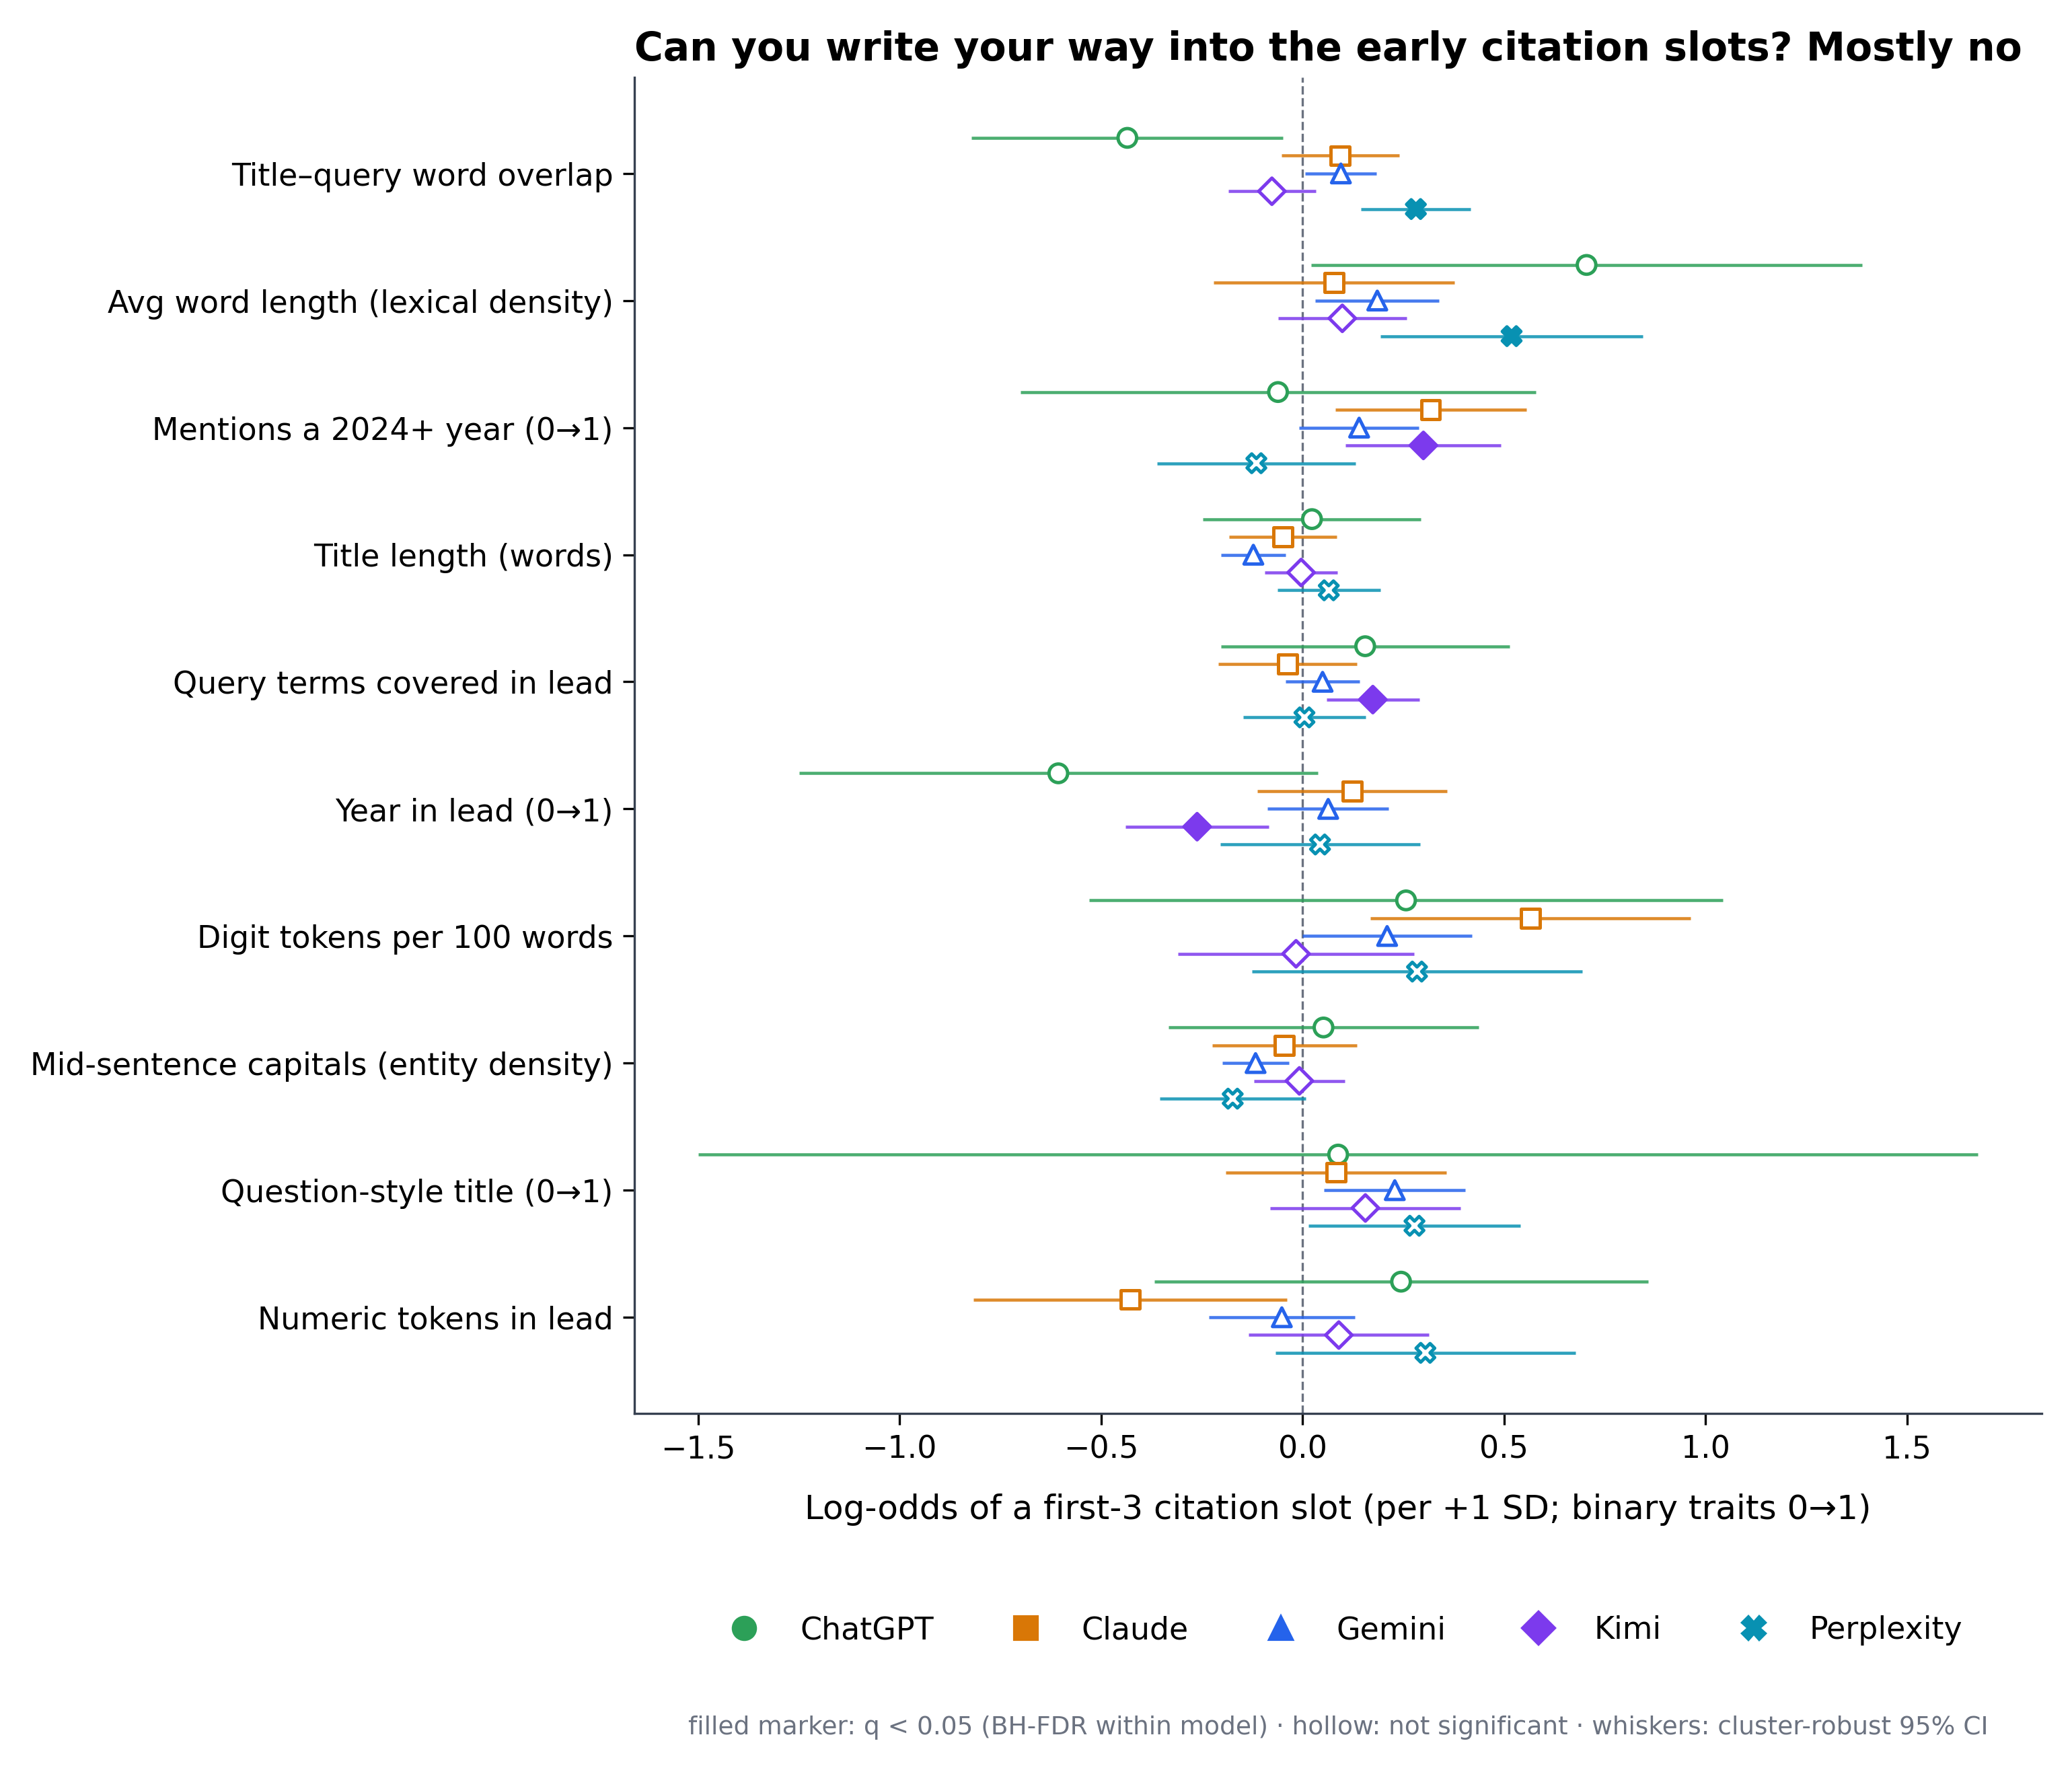

    engine             feature   beta    se      z     q
      kimi lead_query_coverage  0.174 0.059  2.965 0.023
      kimi     has_recent_year  0.300 0.098  3.051 0.023
      kimi       lead_has_year -0.262 0.090 -2.891 0.023
perplexity        avg_word_len  0.519 0.166  3.123 0.016
perplexity title_query_jaccard  0.281 0.070  4.043 0.001


In [3]:
# PF1 · Early-slot model (logit, log-odds per +1 SD): forest of the 10 strongest features across engines.
order = forest(RES, "early3", ENGINE_ORDER, 1.0,
               "Log-odds of a first-3 citation slot (per +1 SD; binary traits 0→1)",
               "Can you write your way into the early citation slots? Mostly no",
               "fig_pf_q1_early3_forest")
b = RES[(RES.outcome == "early3") & (RES.q < 0.05)]
print(b[["engine", "feature", "beta", "se", "z", "q"]].round(3).to_string(index=False))

**Key analysis.** Nearly every marker is hollow: after controlling for who you are (source type) and what the query is about, page writing barely moves citation position. The exceptions are informative, though. On **Perplexity**, a title that literally shares words with the query raises the odds of a first-3 slot (+0.28 log-odds per SD, q = 0.001) — its retrieval is the most lexical of the five. On **Kimi**, pages mentioning a 2024+ year get earlier slots (+0.30 log-odds, 0→1) — a freshness tilt. Everything else, including length, readability, structure and fact density, is noise here. Position is earned at the *site* level (see the domain notebook's D3: Wikipedia and reference sites own the early slots), not the *page* level.

saved fig_pf_q2_support_forest


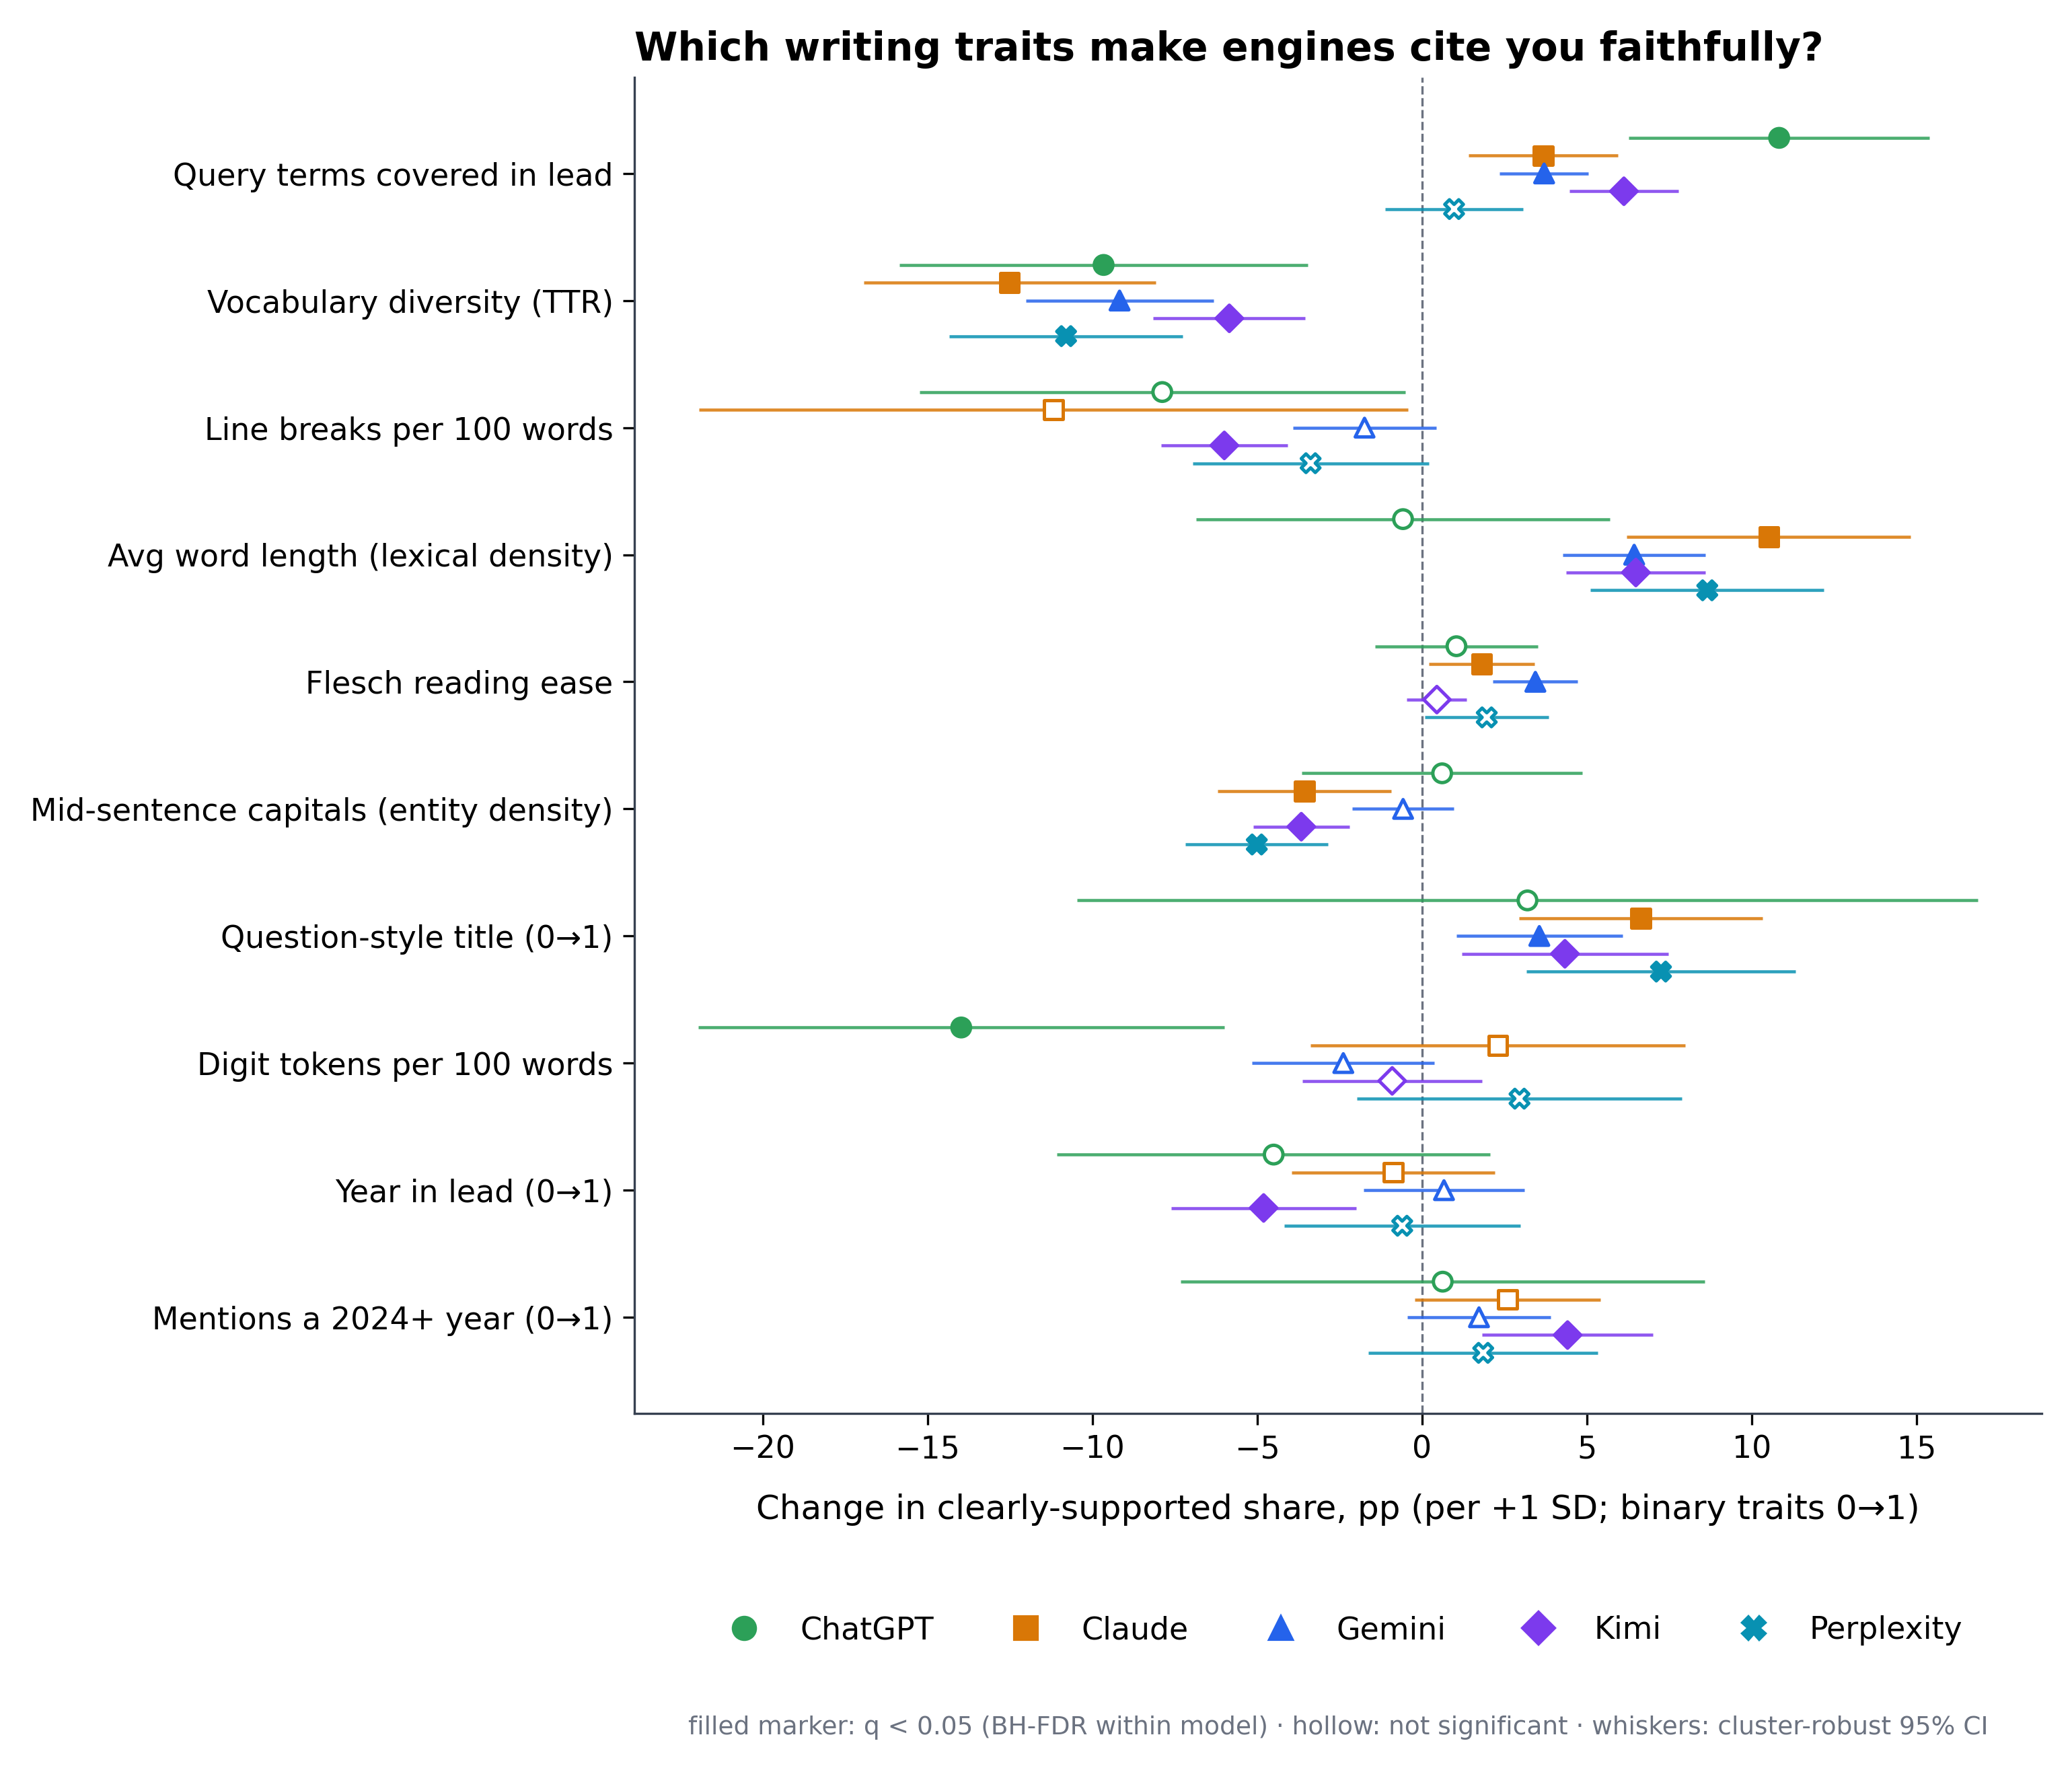

baseline clearly-supported share (%): {'chatgpt': 34.8, 'claude': 37.9, 'gemini': 24.5, 'kimi': 34.8, 'perplexity': 44.6}


In [4]:
# PF2 · Clearly-supported share (OLS, percentage points per +1 SD): forest of the 10 strongest features.
order = forest(RES, "support", ENGINE_ORDER, 100.0,
               "Change in clearly-supported share, pp (per +1 SD; binary traits 0→1)",
               "Which writing traits make engines cite you faithfully?",
               "fig_pf_q2_support_forest")
base = M.groupby("engine").supported_share.mean().mul(100).round(1)
print("baseline clearly-supported share (%):", base.to_dict())

**Key analysis.** This is where writing pays — but read the levers in order of how cleanly you can act on them. The most actionable finding replicates on every engine (baseline shares 24–45%): a **lead that covers the query's own words** raises the clearly-supported share by 4–11 pp per SD (strongest on ChatGPT +10.8 and Kimi +6.1) — answer the question in the opening lines and the engine represents you more accurately. **Question-style titles** add 3–7 pp (significant on four engines), and **denser wording** (longer average words) adds 6–11 pp everywhere except ChatGPT. On the negative side, entity name-dropping (mid-sentence capitals) costs 4–5 pp on Kimi and Perplexity, sprawling pages lose ~3–5 pp on Claude and Kimi, and long titles consistently hurt.

One caveat on the *largest* bar in the chart. Vocabulary diversity (TTR) is a strong negative predictor on every engine, but it is **heavily entangled with page length** — the two correlate −0.84 here, because a short page mechanically repeats fewer words and a giant document repeats many. So the TTR bar should **not** be read as an independent "use a smaller vocabulary" dial; its real shape is page-length-driven and is unpacked in PF5. Stripping that confounded signal out, the durable message is simple: cover the query terms up front, ask-and-answer in the title, keep the prose tight and on one topic — those are the levers that make citations actually check out, across all five engines.

saved fig_pf_q3_sticky_forest_appendix


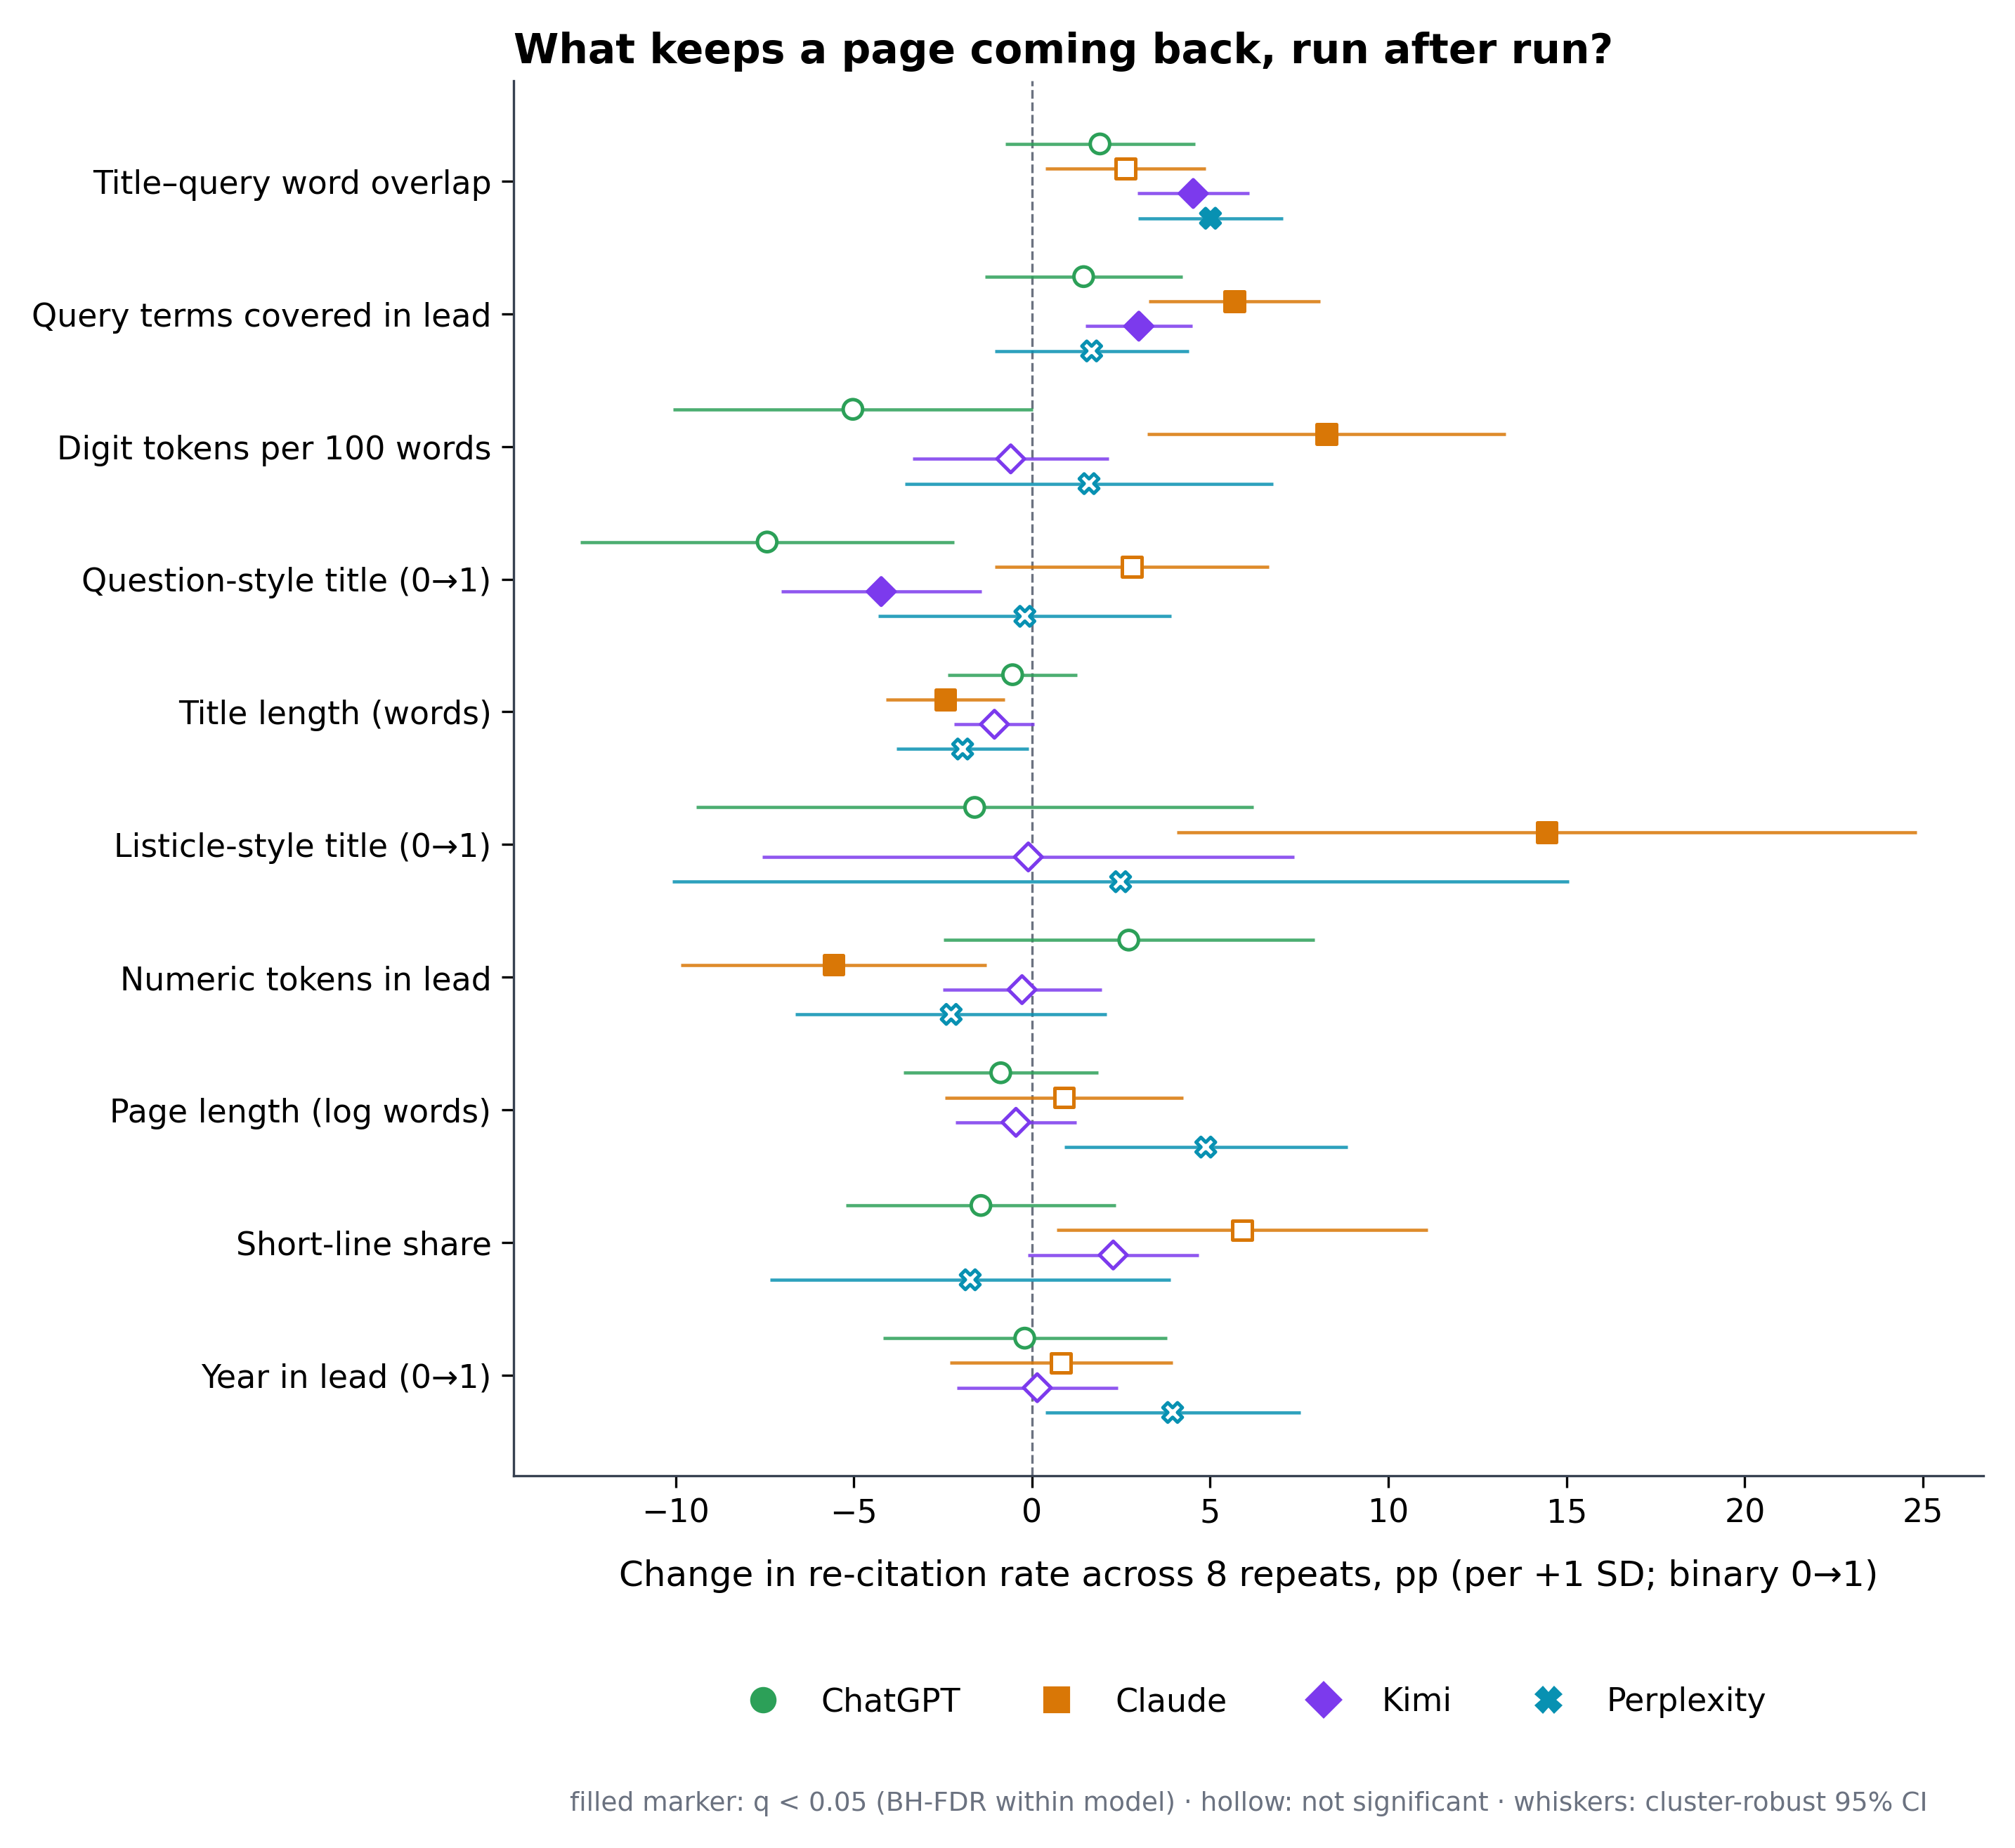

saved fig_pf_q3_sticky_forest


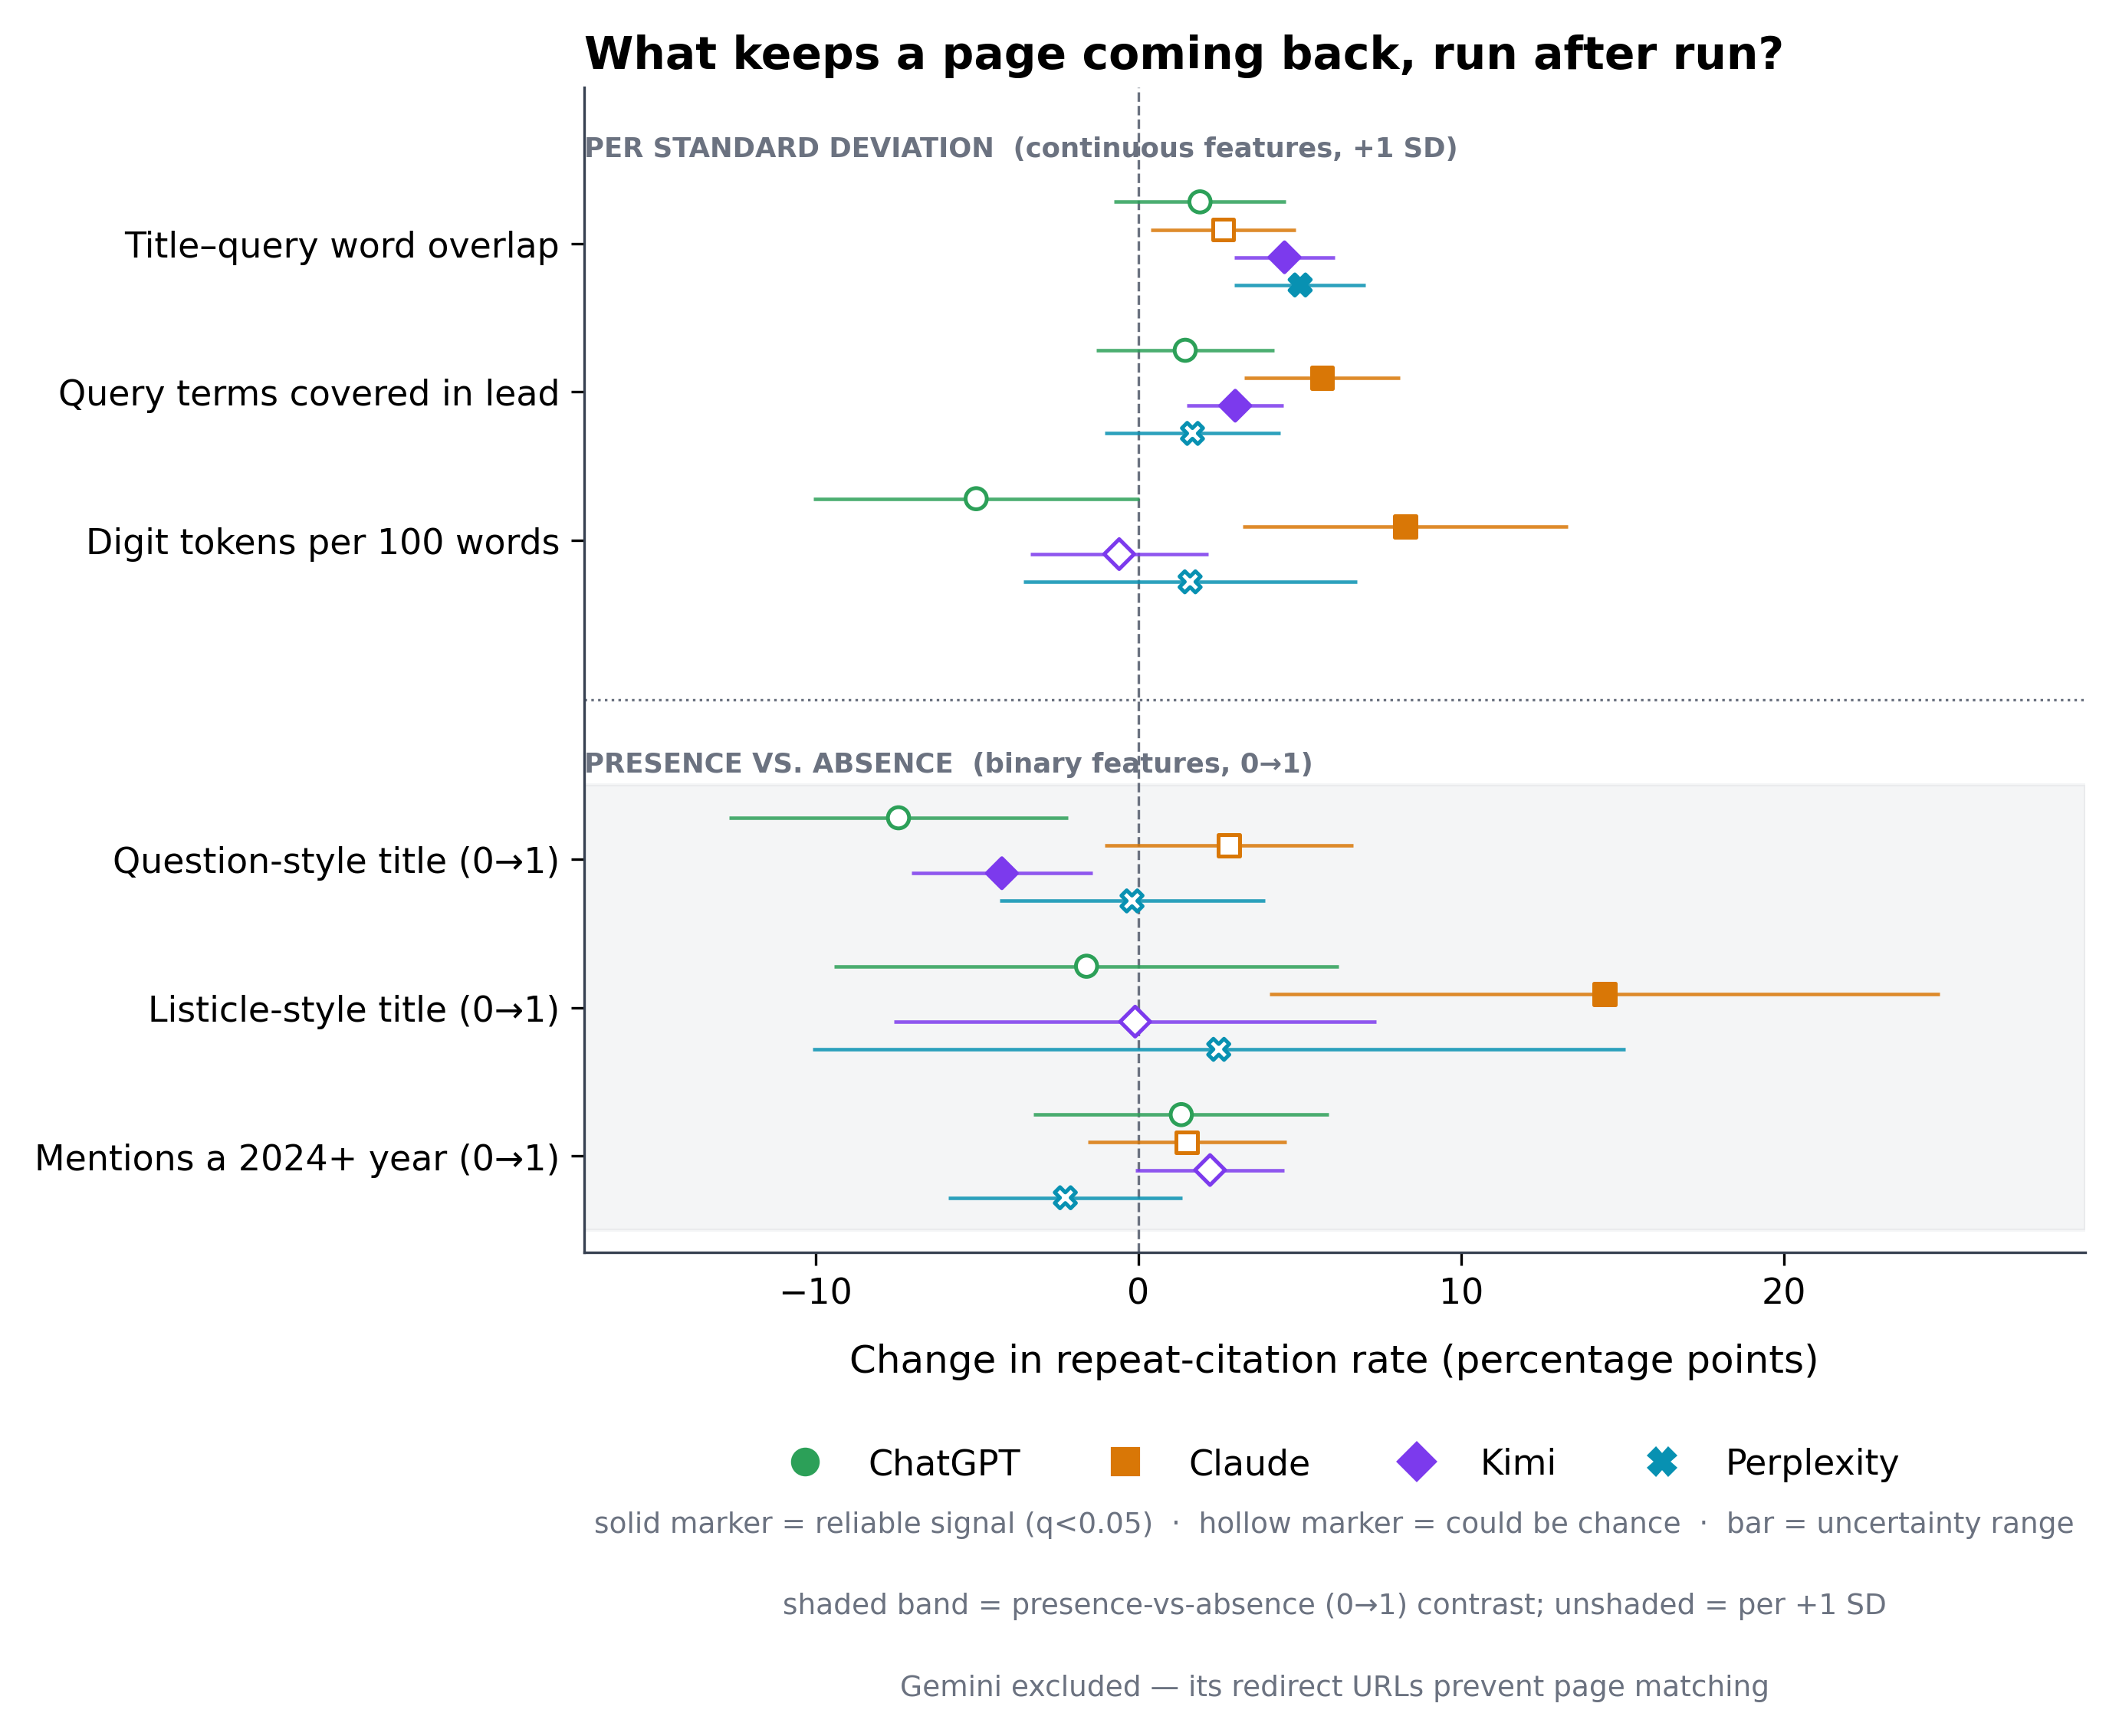

baseline: a cited page recurs in 3.7 of 8 runs on average

Gemini domain-level robustness (q<0.05):
            feature  beta     z     q
   short_line_share 0.030 3.116 0.011
title_query_jaccard 0.024 3.690 0.003
lead_query_coverage 0.020 3.624 0.003


In [5]:
# PF3 · Re-citation across k=8 repeats (OLS, pp per +1 SD), page level — Gemini excluded (redirect URLs).
ENG4 = ["chatgpt", "claude", "kimi", "perplexity"]

# Appendix G: full-feature version (all 10 strongest features). Same fitted results, original layout —
# statistics unchanged; this is the existing forest, only pointed at the "_appendix" basename.
forest(RES, "sticky", ENG4, 100.0,
       "Change in re-citation rate across 8 repeats, pp (per +1 SD; binary 0→1)",
       "What keeps a page coming back, run after run?",
       "fig_pf_q3_sticky_forest_appendix")

# Main figure: DISPLAY filter to the traits the Chapter 4.2 "write for repeat citation" text discusses —
# three per-SD continuous traits (lead query-term coverage, title–query word overlap, digit density) plus
# three presence/absence binary traits (question-style title, recent-year mention, listicle-style title —
# added so Claude's +14.4pp listicle estimate, quoted in the chapter, actually appears on the chart).
# This only chooses which already-fitted rows are drawn — no refit, no changed statistics.
STICKY_MAIN_CONT = ["lead_query_coverage", "title_query_jaccard", "digits_per_100w"]
STICKY_MAIN_BIN = ["title_is_question", "has_recent_year", "title_listicle"]

def _forest_main(res, outcome, engines, scale, xlabel, title, fname, cont_features, bin_features):
    feats_all = cont_features + bin_features
    r = res[(res.outcome == outcome) & (res.engine.isin(engines)) & (res.feature.isin(feats_all))].copy()

    def _sorted(feats):
        z = r[r.feature.isin(feats)].groupby("feature").z.apply(lambda s: s.abs().max())
        return z.sort_values(ascending=False).index.tolist()

    cont_order = _sorted(cont_features)
    bin_order = _sorted(bin_features)
    order = cont_order + bin_order
    n_cont = len(cont_order)
    GAP = 1.15  # extra vertical spacing (row units) that visually separates the two unit-groups

    # y position per row, top to bottom, with an extra gap after the continuous block
    y_pos = np.empty(len(order))
    cur = 0.0
    for i in range(len(order)):
        if i > 0:
            cur -= 1.0 + (GAP if i == n_cont else 0.0)
        y_pos[i] = cur
    y_pos = y_pos - y_pos.min()

    fig, ax = plt.subplots(figsize=(9, 0.62 * (len(order) + GAP) + 2.9), constrained_layout=True)

    # shade the presence-vs-absence (binary) block so its unit is visually unmistakable vs the per-SD block
    if bin_order:
        top_bin, bottom_bin = y_pos[n_cont] + 0.5, y_pos[-1] - 0.5
        ax.axhspan(bottom_bin, top_bin, color=COLOUR_NEUTRAL, alpha=0.07, zorder=0)
        divider_y = (y_pos[n_cont - 1] + y_pos[n_cont]) / 2 if n_cont > 0 else top_bin + 0.3
        ax.axhline(divider_y, color=COLOUR_NEUTRAL, linewidth=0.8, linestyle=":", zorder=1)

    offs = np.linspace(0.28, -0.28, len(engines))
    for oi, eng in enumerate(engines):
        d = r[r.engine == eng].set_index("feature").reindex(order)
        y = y_pos + offs[oi]
        sig = d.q.values < 0.05
        ax.errorbar(d.beta.values * scale, y, xerr=1.96 * d.se.values * scale, fmt="none",
                    ecolor=ENGINE_COLOURS[eng], elinewidth=1.1, capsize=0, alpha=0.85)
        ax.scatter(d.beta.values * scale, y, marker=ENGINE_MARKERS[eng], s=44, zorder=3,
                   facecolors=np.where(sig, ENGINE_COLOURS[eng], "white"),
                   edgecolors=ENGINE_COLOURS[eng], linewidths=1.2)
    ax.axvline(0, color=COLOUR_NEUTRAL, linewidth=0.8, linestyle="--", zorder=1)
    ax.set_yticks(y_pos); ax.set_yticklabels([DISP[f] for f in order])
    ax.set_ylim(y_pos.min() - 0.65, y_pos[0] + 1.05)  # headroom for the section headers above the data

    # section headers make the per-SD vs presence/absence distinction visually unmistakable
    if cont_order:
        ax.text(0.0, y_pos[0] + 0.55, "PER STANDARD DEVIATION  (continuous features, +1 SD)",
                transform=ax.get_yaxis_transform(), ha="left", va="bottom",
                fontsize=8.5, fontweight="bold", color=COLOUR_NEUTRAL)
    if bin_order:
        ax.text(0.0, y_pos[n_cont] + 0.55, "PRESENCE VS. ABSENCE  (binary features, 0→1)",
                transform=ax.get_yaxis_transform(), ha="left", va="bottom",
                fontsize=8.5, fontweight="bold", color=COLOUR_NEUTRAL)

    # x-limits: pad so every plotted point AND its full 95% CI whisker sits inside the axes
    # (Claude's listicle-title estimate/CI is the widest — this must not clip it)
    lo = (r.beta - 1.96 * r.se).min() * scale
    hi = (r.beta + 1.96 * r.se).max() * scale
    pad = 0.12 * (hi - lo)
    ax.set_xlim(lo - pad, hi + pad)

    ax.set_xlabel(xlabel); ax.set_title(title, loc="left")
    apply_style(ax); ax.grid(False)
    handles = [Line2D([], [], color=ENGINE_COLOURS[e], marker=ENGINE_MARKERS[e], linestyle="none",
                      markersize=8, label=ENGINE_LABELS[e]) for e in engines]
    ax.legend(handles=handles, ncol=len(engines), loc="upper center", bbox_to_anchor=(0.5, -0.14))
    ax.text(0.5, -0.24, "solid marker = reliable signal (q<0.05)  ·  hollow marker = could be chance  ·  bar = uncertainty range",
            transform=ax.transAxes, ha="center", fontsize=9, color=COLOUR_NEUTRAL)
    ax.text(0.5, -0.31, "shaded band = presence-vs-absence (0→1) contrast; unshaded = per +1 SD",
            transform=ax.transAxes, ha="center", fontsize=9, color=COLOUR_NEUTRAL)
    ax.text(0.5, -0.38, "Gemini excluded — its redirect URLs prevent page matching",
            transform=ax.transAxes, ha="center", fontsize=9, color=COLOUR_NEUTRAL)
    savefig(fig, fname); plt.show()
    return order

order = _forest_main(RES, "sticky", ENG4, 100.0,
                     "Change in repeat-citation rate (percentage points)",
                     "What keeps a page coming back, run after run?",
                     "fig_pf_q3_sticky_forest", STICKY_MAIN_CONT, STICKY_MAIN_BIN)
print("baseline: a cited page recurs in", round(ST.stickiness.mean() * 8, 1), "of 8 runs on average")
gd = RES[(RES.outcome == "sticky_domain") & (RES.engine == "gemini") & (RES.q < 0.05)]
print("\nGemini domain-level robustness (q<0.05):")
print(gd[["feature", "beta", "z", "q"]].round(3).to_string(index=False))

**Key analysis.** Re-citation is a *relevance-match* game. The dominant significant traits are literal query matching: title–query word overlap (Kimi +4.5 pp per SD, Perplexity +5.0) and query terms covered in the lead (Claude +5.7, Kimi +3.0). Claude adds a taste for numbers: digit-dense pages (+8.3 pp per SD) and listicle-style titles (+14.4 pp, 0→1) recur more. The Gemini domain-level robustness model — the only stickiness Gemini's redirect URLs allow — agrees on the same two query-match traits. ChatGPT shows nothing significant, consistent with its small sample (556 page–query pairs) and its search gate being the real bottleneck. For a GEO manager this is the closest thing to classic SEO in the generative world: old-fashioned keyword relevance in the title and opening lines is what makes an AI citation *stable* rather than a one-off lottery win.

saved fig_pf_q4_support_z_heatmap


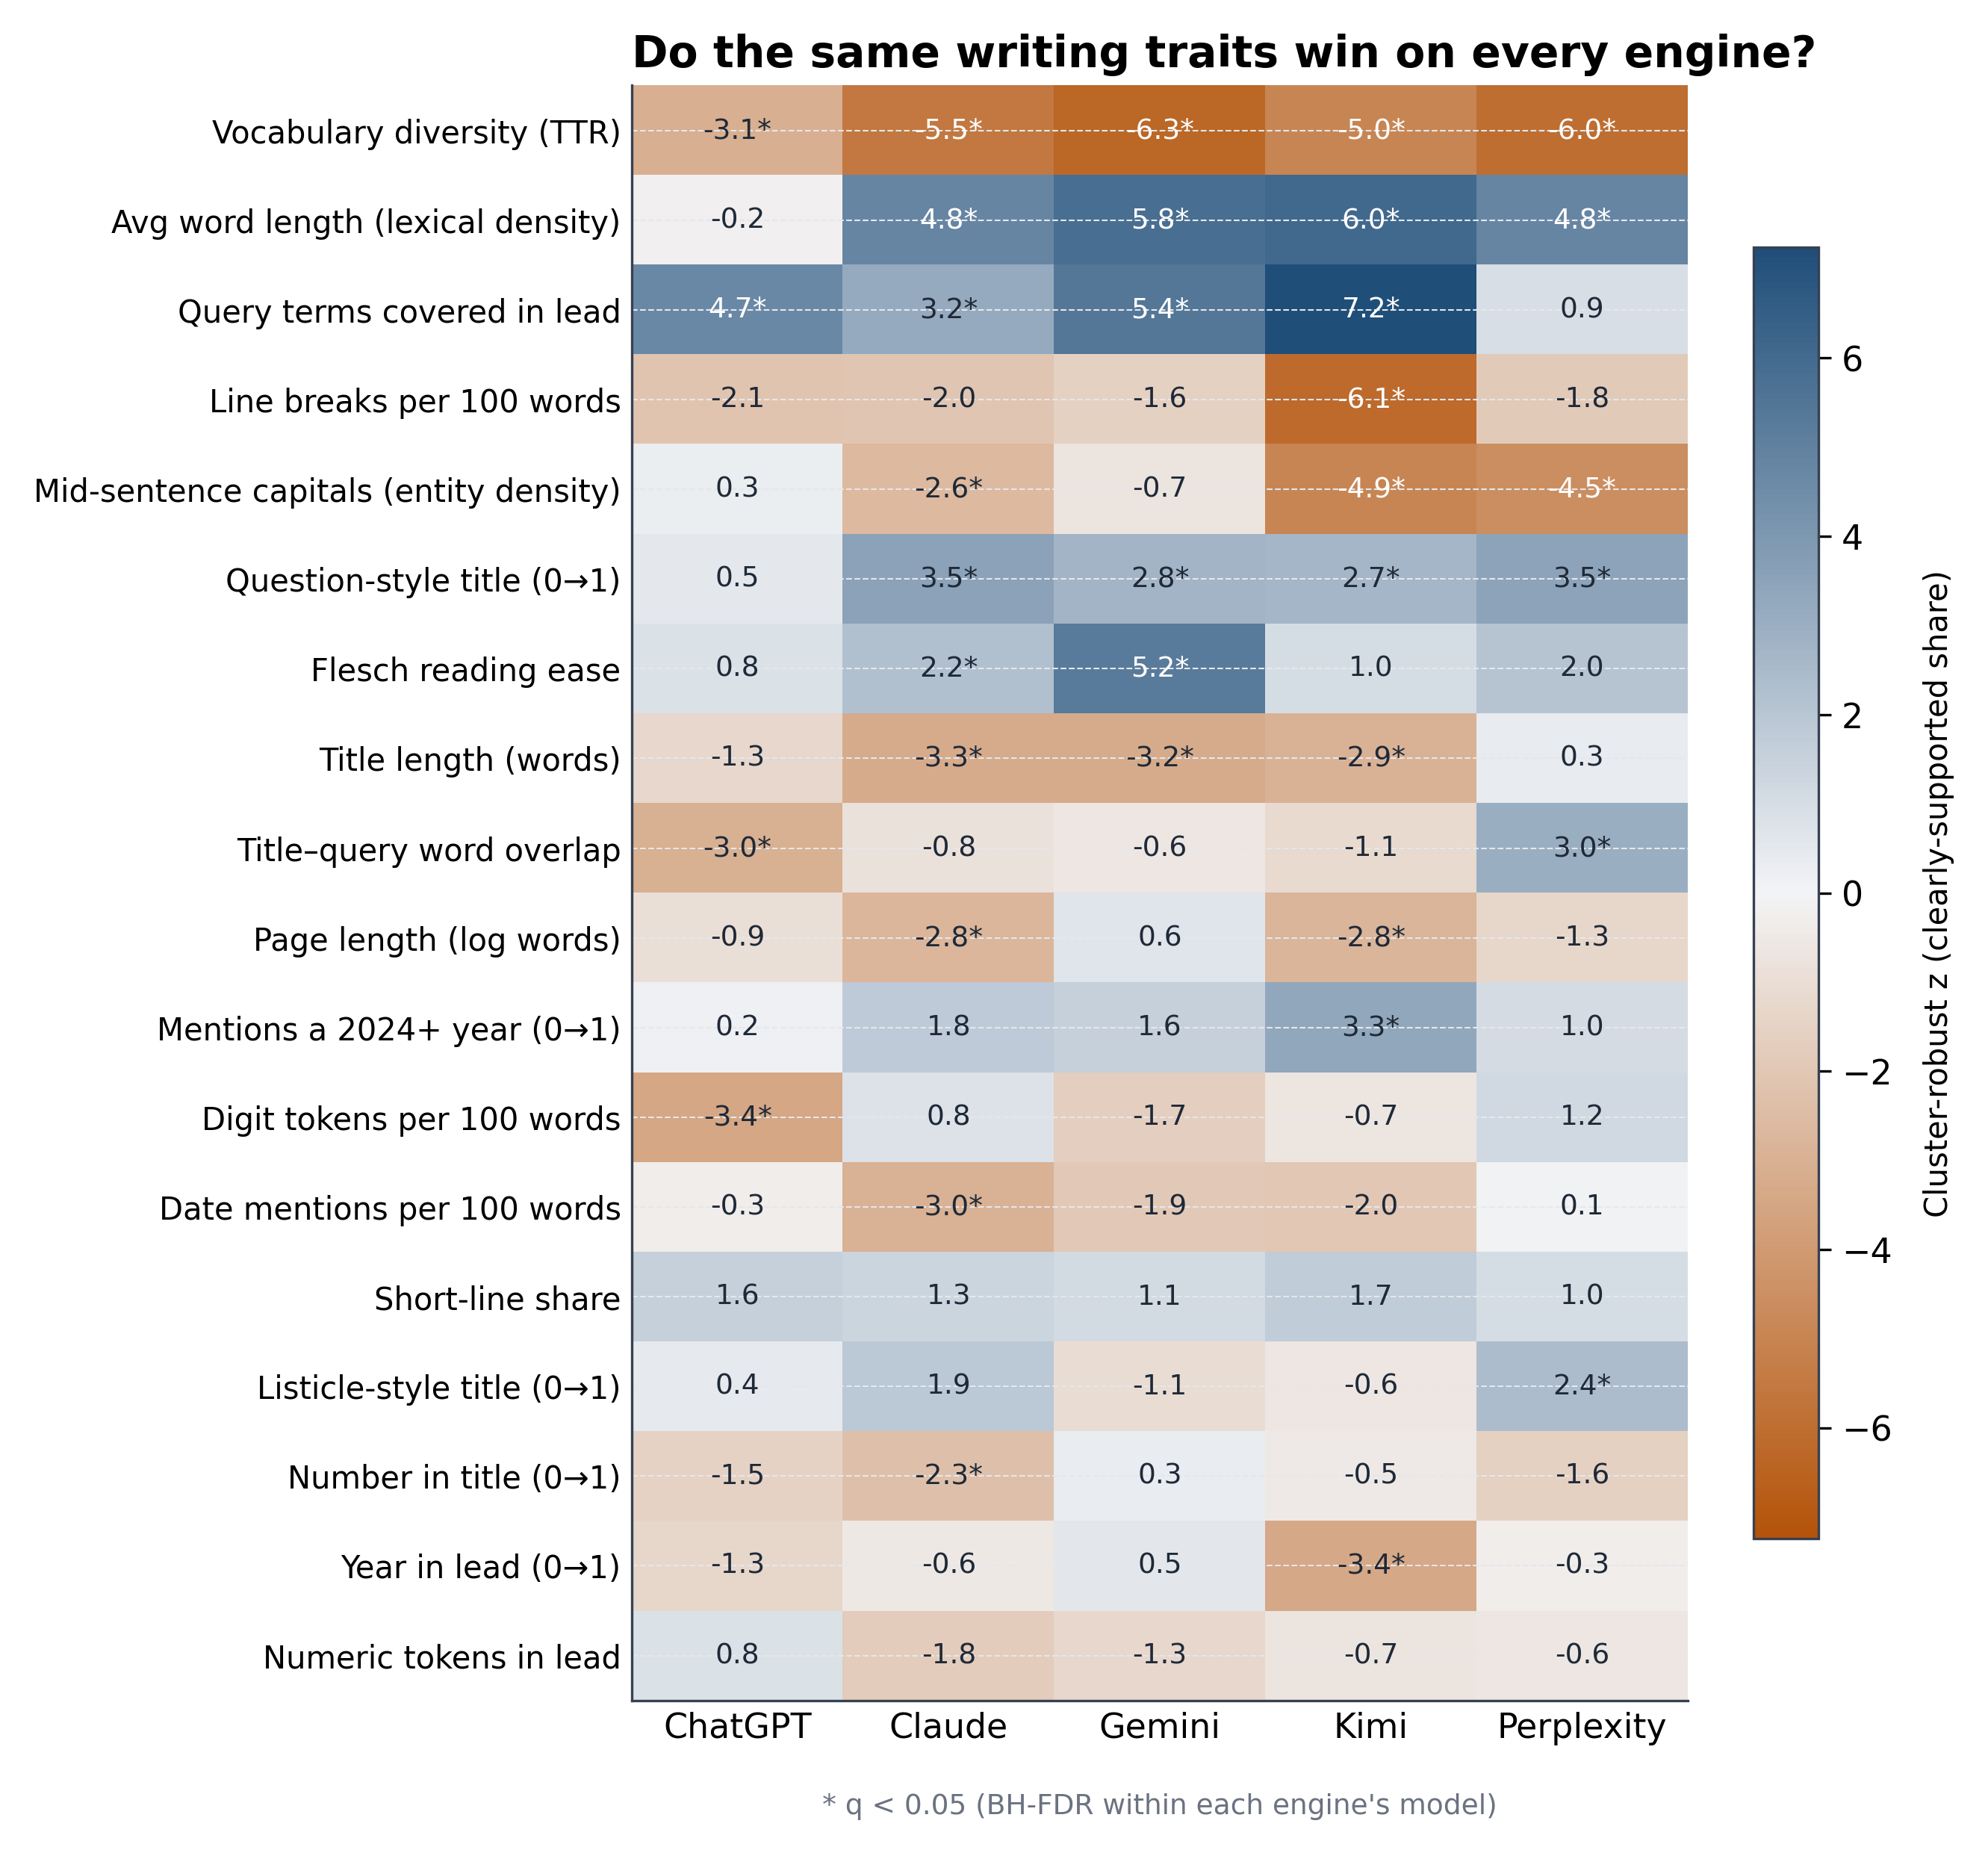

features with the same sign on all five engines: ['ttr_1000', 'lead_query_coverage', 'newlines_per_100w', 'title_is_question', 'flesch_c', 'has_recent_year', 'short_line_share']


In [6]:
# PF4 · Cross-engine consistency heatmap: support-model z-scores, all measurable features, * = q<0.05.
r = RES[RES.outcome == "support"]
featord = r.groupby("feature").z.apply(lambda s: s.abs().mean()).sort_values(ascending=False).index.tolist()
Z = r.pivot_table(index="feature", columns="engine", values="z").reindex(featord)[ENGINE_ORDER]
Q = r.pivot_table(index="feature", columns="engine", values="q").reindex(featord)[ENGINE_ORDER]
vmax = np.nanmax(np.abs(Z.values))
fig, ax = plt.subplots(figsize=(7.6, 0.42 * len(featord) + 1.8))
im = ax.imshow(Z.values, cmap=CMAP_DIVERGENT, vmin=-vmax, vmax=vmax, aspect="auto")
for i in range(Z.shape[0]):
    for j in range(Z.shape[1]):
        v = Z.values[i, j]; qv = Q.values[i, j]
        col = "white" if abs(v) > 0.55 * vmax else "#1F2937"
        ax.text(j, i, f"{v:.1f}" + ("*" if qv < 0.05 else ""), ha="center", va="center", fontsize=9, color=col)
ax.set_xticks(range(5)); ax.set_xticklabels([ENGINE_LABELS[e] for e in ENGINE_ORDER])
ax.set_yticks(range(len(featord))); ax.set_yticklabels([DISP[f] for f in featord], fontsize=10)
ax.set_title("Do the same writing traits win on every engine?", loc="left")
cb = fig.colorbar(im, ax=ax, shrink=0.8); cb.set_label("Cluster-robust z (clearly-supported share)", fontsize=10)
ax.tick_params(length=0)
ax.text(0.5, -0.07, "* q < 0.05 (BH-FDR within each engine's model)", transform=ax.transAxes, ha="center", fontsize=9, color=COLOUR_NEUTRAL)
savefig(fig, "fig_pf_q4_support_z_heatmap"); plt.show()
agree = ((Z.values > 0).all(axis=1) | (Z.values < 0).all(axis=1))
print("features with the same sign on all five engines:", [featord[i] for i in np.where(agree)[0]])

**Key analysis.** The heatmap answers the transferability worry from RQ2: cross-engine *visibility* barely correlates, but the writing traits behind *faithful* citation largely do. Vocabulary focus, lexical density, question titles, lead–query coverage, shorter titles and tighter pages point the same way on essentially every engine — one writing playbook serves all five, differing in degree, not direction. The visible exception is **ChatGPT**, which flips sign on several traits (digit density, title–query overlap): with only ~1,000 events behind it, treat its cells as directional at best. This is the practical resolution for a GEO team: per-engine *targeting* (RQ1) plus a single, engine-agnostic *writing standard* for faithfulness.

saved fig_pf_q5_length_deciles


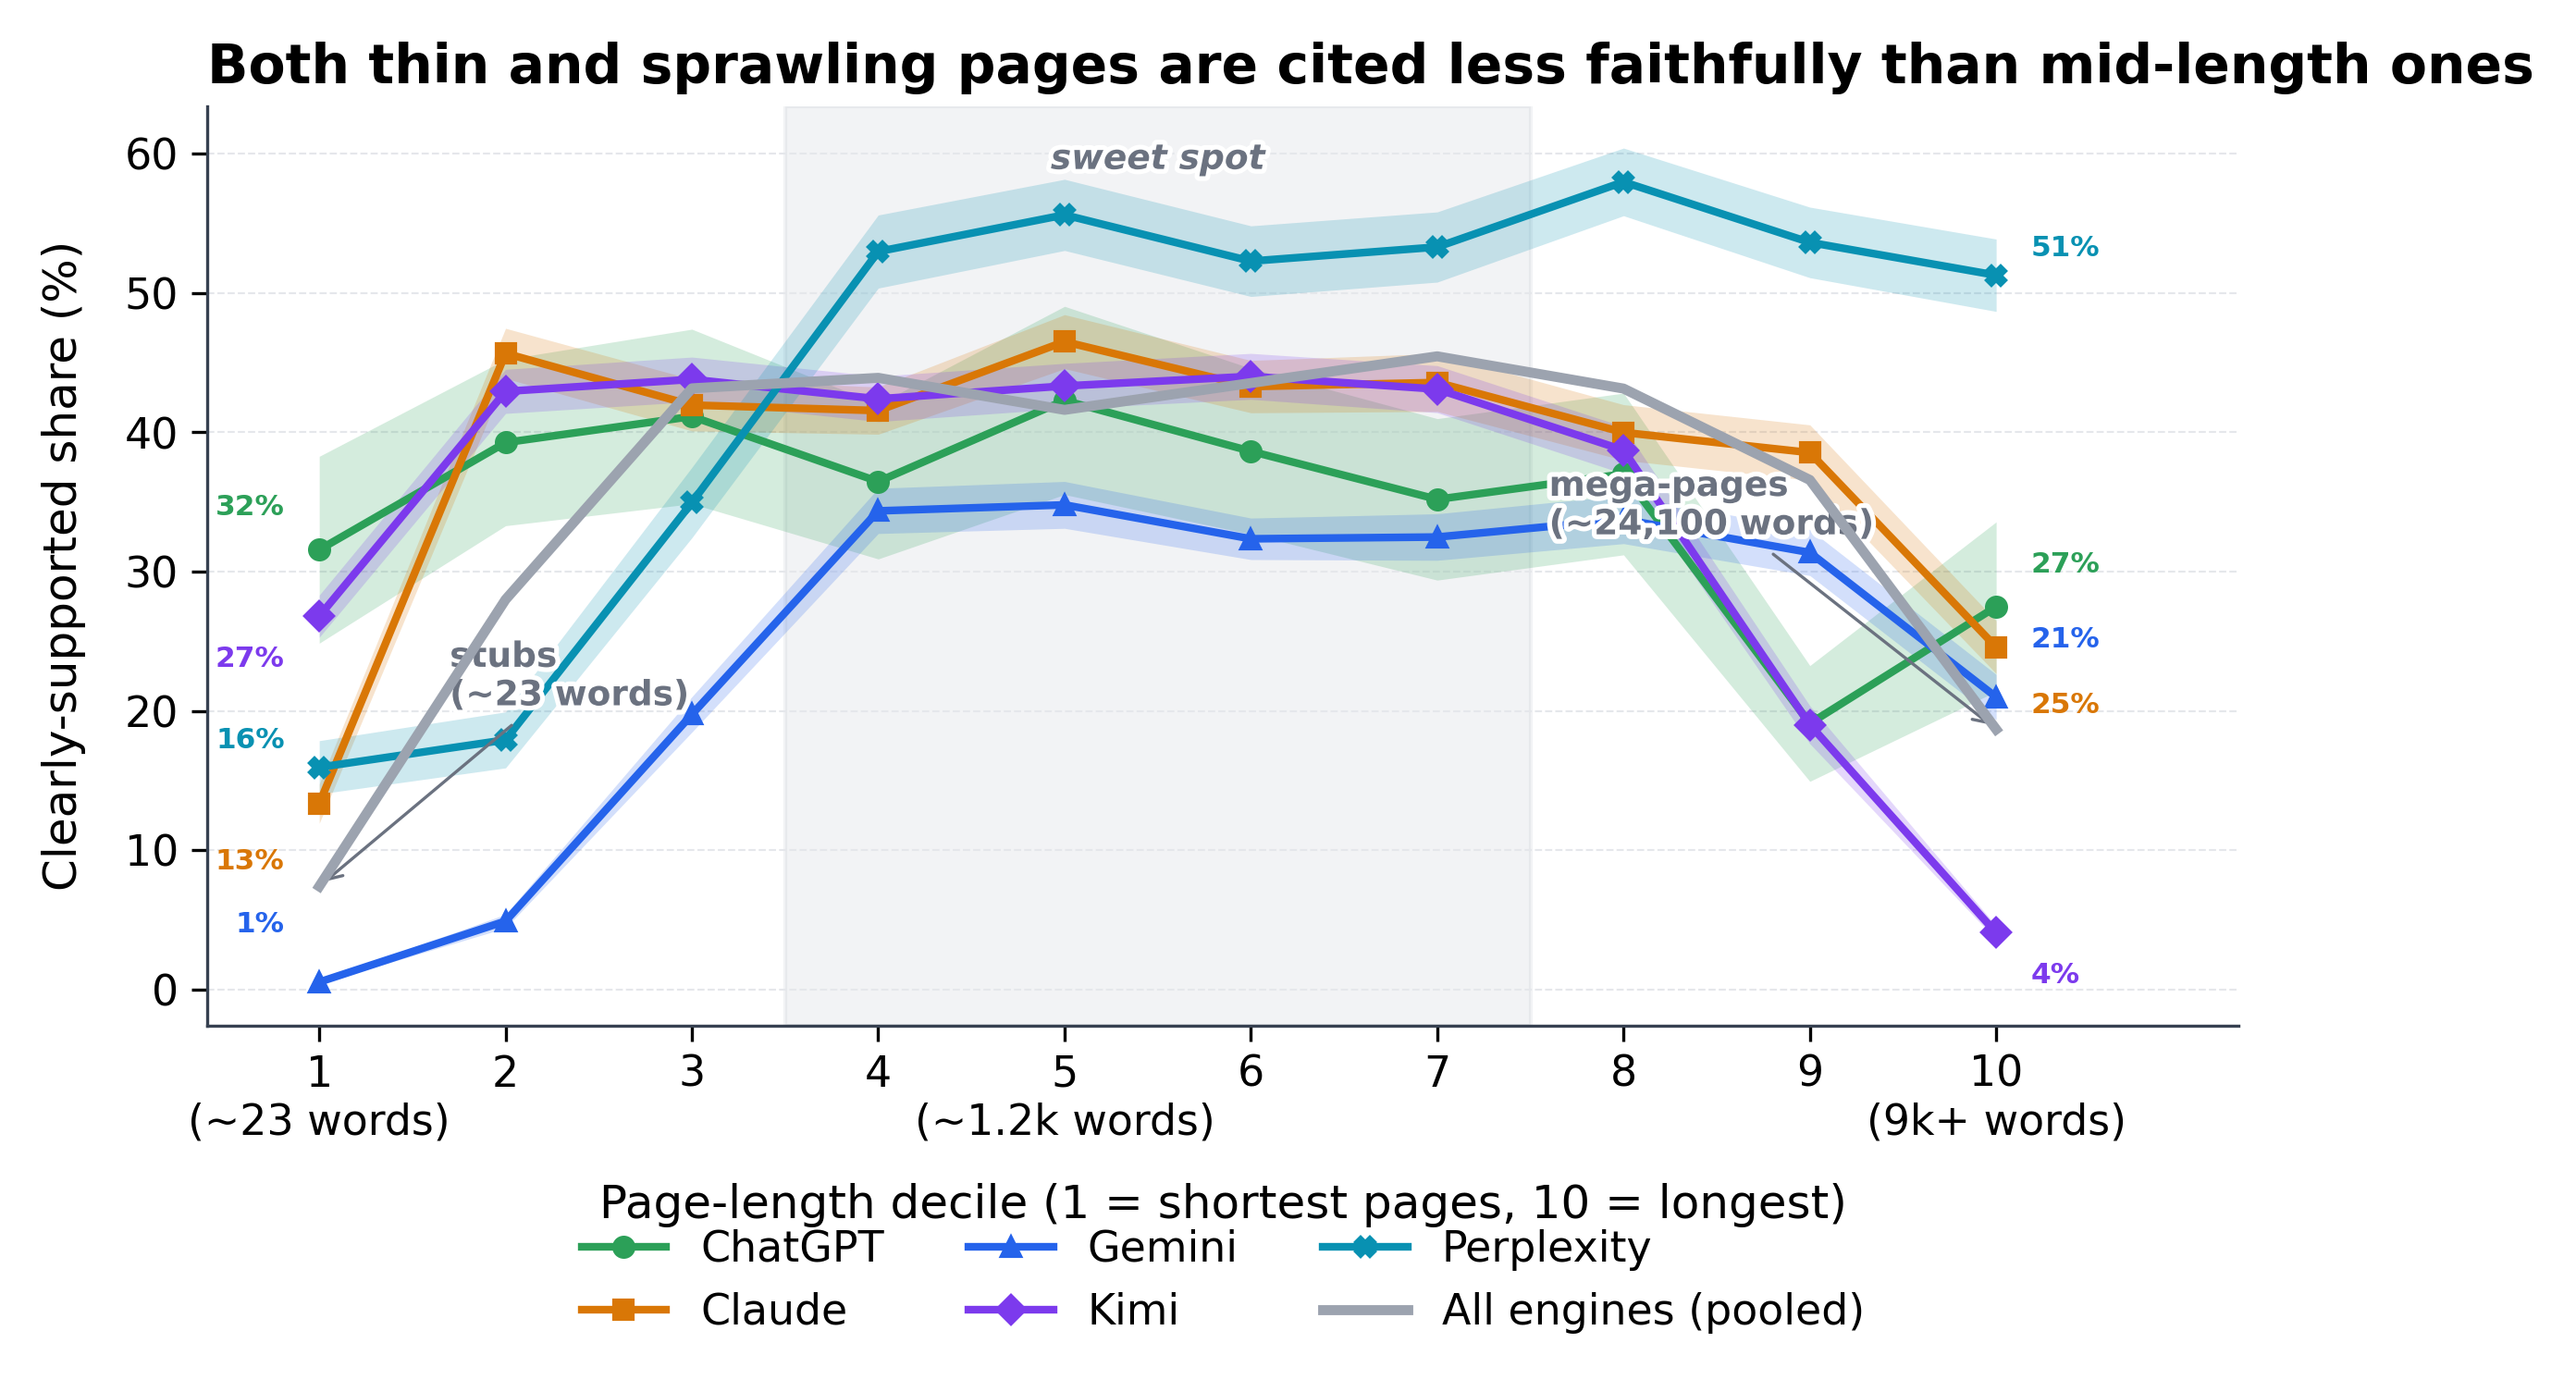

pooled clearly-supported share — decile 1: 7.4 % · decile 10: 18.7 %


In [7]:
import matplotlib.patheffects as pe
_HALO = [pe.withStroke(linewidth=2.5, foreground="white")]  # thin white halo -> text stays crisp over the lines
# PF5 · Raw descriptive check: clearly-supported share by PAGE-LENGTH decile (the real driver behind
#        the PF2 vocabulary-diversity effect; TTR correlates -0.84 with length). No covariates.
fig, ax = plt.subplots(figsize=(8, 4.8), constrained_layout=True)
# lightly shade the mid-length "sweet spot" deciles (neutral grey — not an engine colour)
ax.axvspan(3.5, 7.5, color="#9CA3AF", alpha=0.12, zorder=0)
LABEL_DY = {"chatgpt": 11, "claude": -15, "gemini": 15, "kimi": -11, "perplexity": 7}  # px offsets so the 10 data labels don't collide
med_words = {}
for eng in ENGINE_ORDER:
    d = M[(M.engine == eng) & M.supported_share.notna()].copy()
    d["dec"] = pd.qcut(d.n_words, 10, labels=False, duplicates="drop")
    g = d.groupby("dec").supported_share.agg(["mean", "sem", "size"])
    x = g.index.values + 1
    ax.plot(x, g["mean"] * 100, marker=ENGINE_MARKERS[eng], markersize=5, linewidth=2,
            color=ENGINE_COLOURS[eng], label=ENGINE_LABELS[eng], zorder=3)
    ax.fill_between(x, (g["mean"] - 1.96 * g["sem"]) * 100, (g["mean"] + 1.96 * g["sem"]) * 100,
                    color=ENGINE_COLOURS[eng], alpha=0.2, linewidth=0)
    # direct data labels on the first and tenth decile point of every per-engine curve
    v1, v10 = g["mean"].iloc[0] * 100, g["mean"].iloc[-1] * 100
    dy = LABEL_DY[eng]
    ax.annotate(f"{v1:.0f}%", xy=(x[0], v1), xytext=(-9, dy), textcoords="offset points",
                fontsize=7.5, color=ENGINE_COLOURS[eng], ha="right", va="center", fontweight="bold", zorder=5)
    ax.annotate(f"{v10:.0f}%", xy=(x[-1], v10), xytext=(9, dy), textcoords="offset points",
                fontsize=7.5, color=ENGINE_COLOURS[eng], ha="left", va="center", fontweight="bold", zorder=5)
    med_words = M[M.supported_share.notna()].assign(dec=lambda t: pd.qcut(t.n_words, 10, labels=False, duplicates="drop")+1).groupby("dec").n_words.median()

# pooled all-engine mean curve (neutral grey, no marker), drawn over the per-engine curves
dpool = M[M.supported_share.notna()].copy()
dpool["dec"] = pd.qcut(dpool.n_words, 10, labels=False, duplicates="drop")
gpool = dpool.groupby("dec").supported_share.agg(["mean", "sem", "size"])
xpool = gpool.index.values + 1
ax.plot(xpool, gpool["mean"] * 100, color="#9CA3AF", linewidth=2.6, linestyle="-", zorder=4, label="All engines (pooled)")
pooled_v1, pooled_v10 = gpool["mean"].iloc[0] * 100, gpool["mean"].iloc[-1] * 100

# real decile boundaries from the pooled page-length data, for readable tick labels
edges = pd.qcut(M[M.supported_share.notna()].n_words, 10, duplicates="drop", retbins=True)[1]
def _fmt_words(w):
    w = float(w)
    if w < 1000: return f"{int(round(w))}"
    k = w / 1000.0
    return f"{k:.0f}k" if abs(k - round(k)) < 0.05 else f"{k:.1f}k"
ax.set_xlabel("Page-length decile (1 = shortest pages, 10 = longest)")
ax.set_ylabel("Clearly-supported share (%)")
ax.set_title("Both thin and sprawling pages are cited less faithfully than mid-length ones", loc="left")
ax.set_xticks(range(1, 11))
ticklabels = [str(i) for i in range(1, 11)]
ticklabels[0] = f"1\n(~{_fmt_words(med_words.loc[1])} words)"
ticklabels[4] = f"5\n(~{_fmt_words(med_words.loc[5])} words)"
ticklabels[9] = f"10\n({_fmt_words(edges[9])}+ words)"
ax.set_xticklabels(ticklabels)
apply_style(ax)
ax.set_xlim(0.4, 11.3)  # headroom on the right for the decile-10 data labels
# label the shaded band
ax.text(5.5, 0.96, "sweet spot", transform=ax.get_xaxis_transform(),
        ha="center", va="top", fontsize=9, fontweight="bold", color=COLOUR_NEUTRAL, style="italic", path_effects=_HALO)
# annotate the two extremes with their median word counts — arrows anchored to the ACTUAL computed
# pooled mean at decile 1 / decile 10 (not hand-typed): the confound behind the PF2 TTR effect
ax.annotate(f"stubs\n(~{int(med_words.loc[1])} words)", xy=(1, pooled_v1), xytext=(1.7, pooled_v1 + 13),
            fontsize=9, fontweight="bold", color=COLOUR_NEUTRAL, ha="left", path_effects=_HALO,
            arrowprops=dict(arrowstyle="->", color=COLOUR_NEUTRAL, lw=0.8))
ax.annotate(f"mega-pages\n(~{int(round(med_words.loc[10], -2)):,} words)", xy=(10, pooled_v10), xytext=(7.6, pooled_v10 + 14),
            fontsize=9, fontweight="bold", color=COLOUR_NEUTRAL, ha="left", path_effects=_HALO,
            arrowprops=dict(arrowstyle="->", color=COLOUR_NEUTRAL, lw=0.8))
ax.legend(ncol=3, loc="upper center", bbox_to_anchor=(0.5, -0.18))
savefig(fig, "fig_pf_q5_length_deciles"); plt.show()
print("pooled clearly-supported share — decile 1:", round(pooled_v1, 1), "% · decile 10:", round(pooled_v10, 1), "%")

**Key analysis.** This is the honest version of the vocabulary-diversity effect from PF2, and it reveals a shape a single linear coefficient hides. Plotted against **page length**, the clearly-supported share is an **inverted-U on every engine**: the thinnest pages (a stub with barely enough text for a claim to rest on) and the most sprawling mega-documents (10,000+ words, where the cited sentence is buried among thousands) both sit well below the middle, while ordinary mid-length articles verify best. This is exactly why the PF2 TTR bar must be read with care — low vocabulary diversity mostly *marks* those giant documents rather than tighter writing (the two correlate −0.84), so "lower TTR is better" is really "mega-pages are worse", pointing the same statistical direction for a completely different reason. The clean, non-confounded levers stay the ones from PF2 and PF3: cover the query's terms up front, and title the page as the question it answers. For length itself, the actionable rule is a middle, not an extreme — a normal-length article on one topic, neither a stub nor an everything-page.

---

### Scope and caveats (read before quoting)

1. **Selection**: only cited pages are observable. Nothing here estimates the probability of *getting* cited — a control corpus of uncited pages would be needed for that.
2. **Association, not causation**: effects are adjusted for topic, intent, source type and citation count, and SEs are clustered by site — but unobserved page/site quality can still confound. The definitive test is a field experiment (edit pages, re-query, watch treatment change).
3. **Snapshot drift**: page text was fetched days after the engines cited it; pages may have changed in between.
4. **Fetch survivorship**: 18.7% of events had no fetchable text and are absent; sites that block crawlers are systematically missing.
5. **Layout features are unmeasurable here**: bulleted lines, question headings and nav clutter are destroyed by HTML cleaning (≥99% zeros) and were auto-dropped — testing them requires the raw HTML staging.
6. **Collinear features are not independent dials**: vocabulary diversity (TTR) correlates −0.84 with page length, and average word length 0.48 with TTR. Their coefficients are directionally reliable but should be interpreted as a *bundle* ("mid-length, focused, moderately technical prose"), not as separately tunable levers. PF5 shows the page-length view that de-confounds the largest of them.
7. **Gemini page identity**: per-response redirect URLs make page-level stickiness unobservable; the domain-level model is the honest substitute.
8. **ChatGPT power**: ~1,000 events, 296 site clusters — its cells are noisy and its sign flips should not be over-read.
9. **NLI, not humans**: "clearly supported" is a DeBERTa-v3 MNLI band (≥0.50), inherited verbatim from RQ3, on artifact-cleaned sentences.

## Appendix C — support-model forest (C2) and pooled re-citation forest (C3)

Two appendix figures backing the Appendix-C correlation audit. **C2** shows the full support-model coefficient set per engine
(all 18 modelled features) in the Figure-13 convention (filled = q < 0.05 BH-FDR, hollow = not significant, whiskers =
cluster-robust 95% CI). **C3** pools the re-citation (stickiness) estimates across the four engines with observable page
identity — ChatGPT, Claude, Kimi and Perplexity — by fixed-effect inverse-variance meta-analysis (Gemini is excluded, as its
per-response redirect URLs make page identity unobservable across runs). On both, the amber-highlighted **‡** rows are the
collinear lexical query-match pair (lead query coverage and title–query word overlap, Spearman ρ = +0.73 in the C-matrix):
they carry a shared signal and should be read as one lever, not two independent effects. Both saved to figures/scaleup/.

saved fig_pf_C2_support_forest


also saved fig_pf_C2_support_forest -> figures/scaleup/


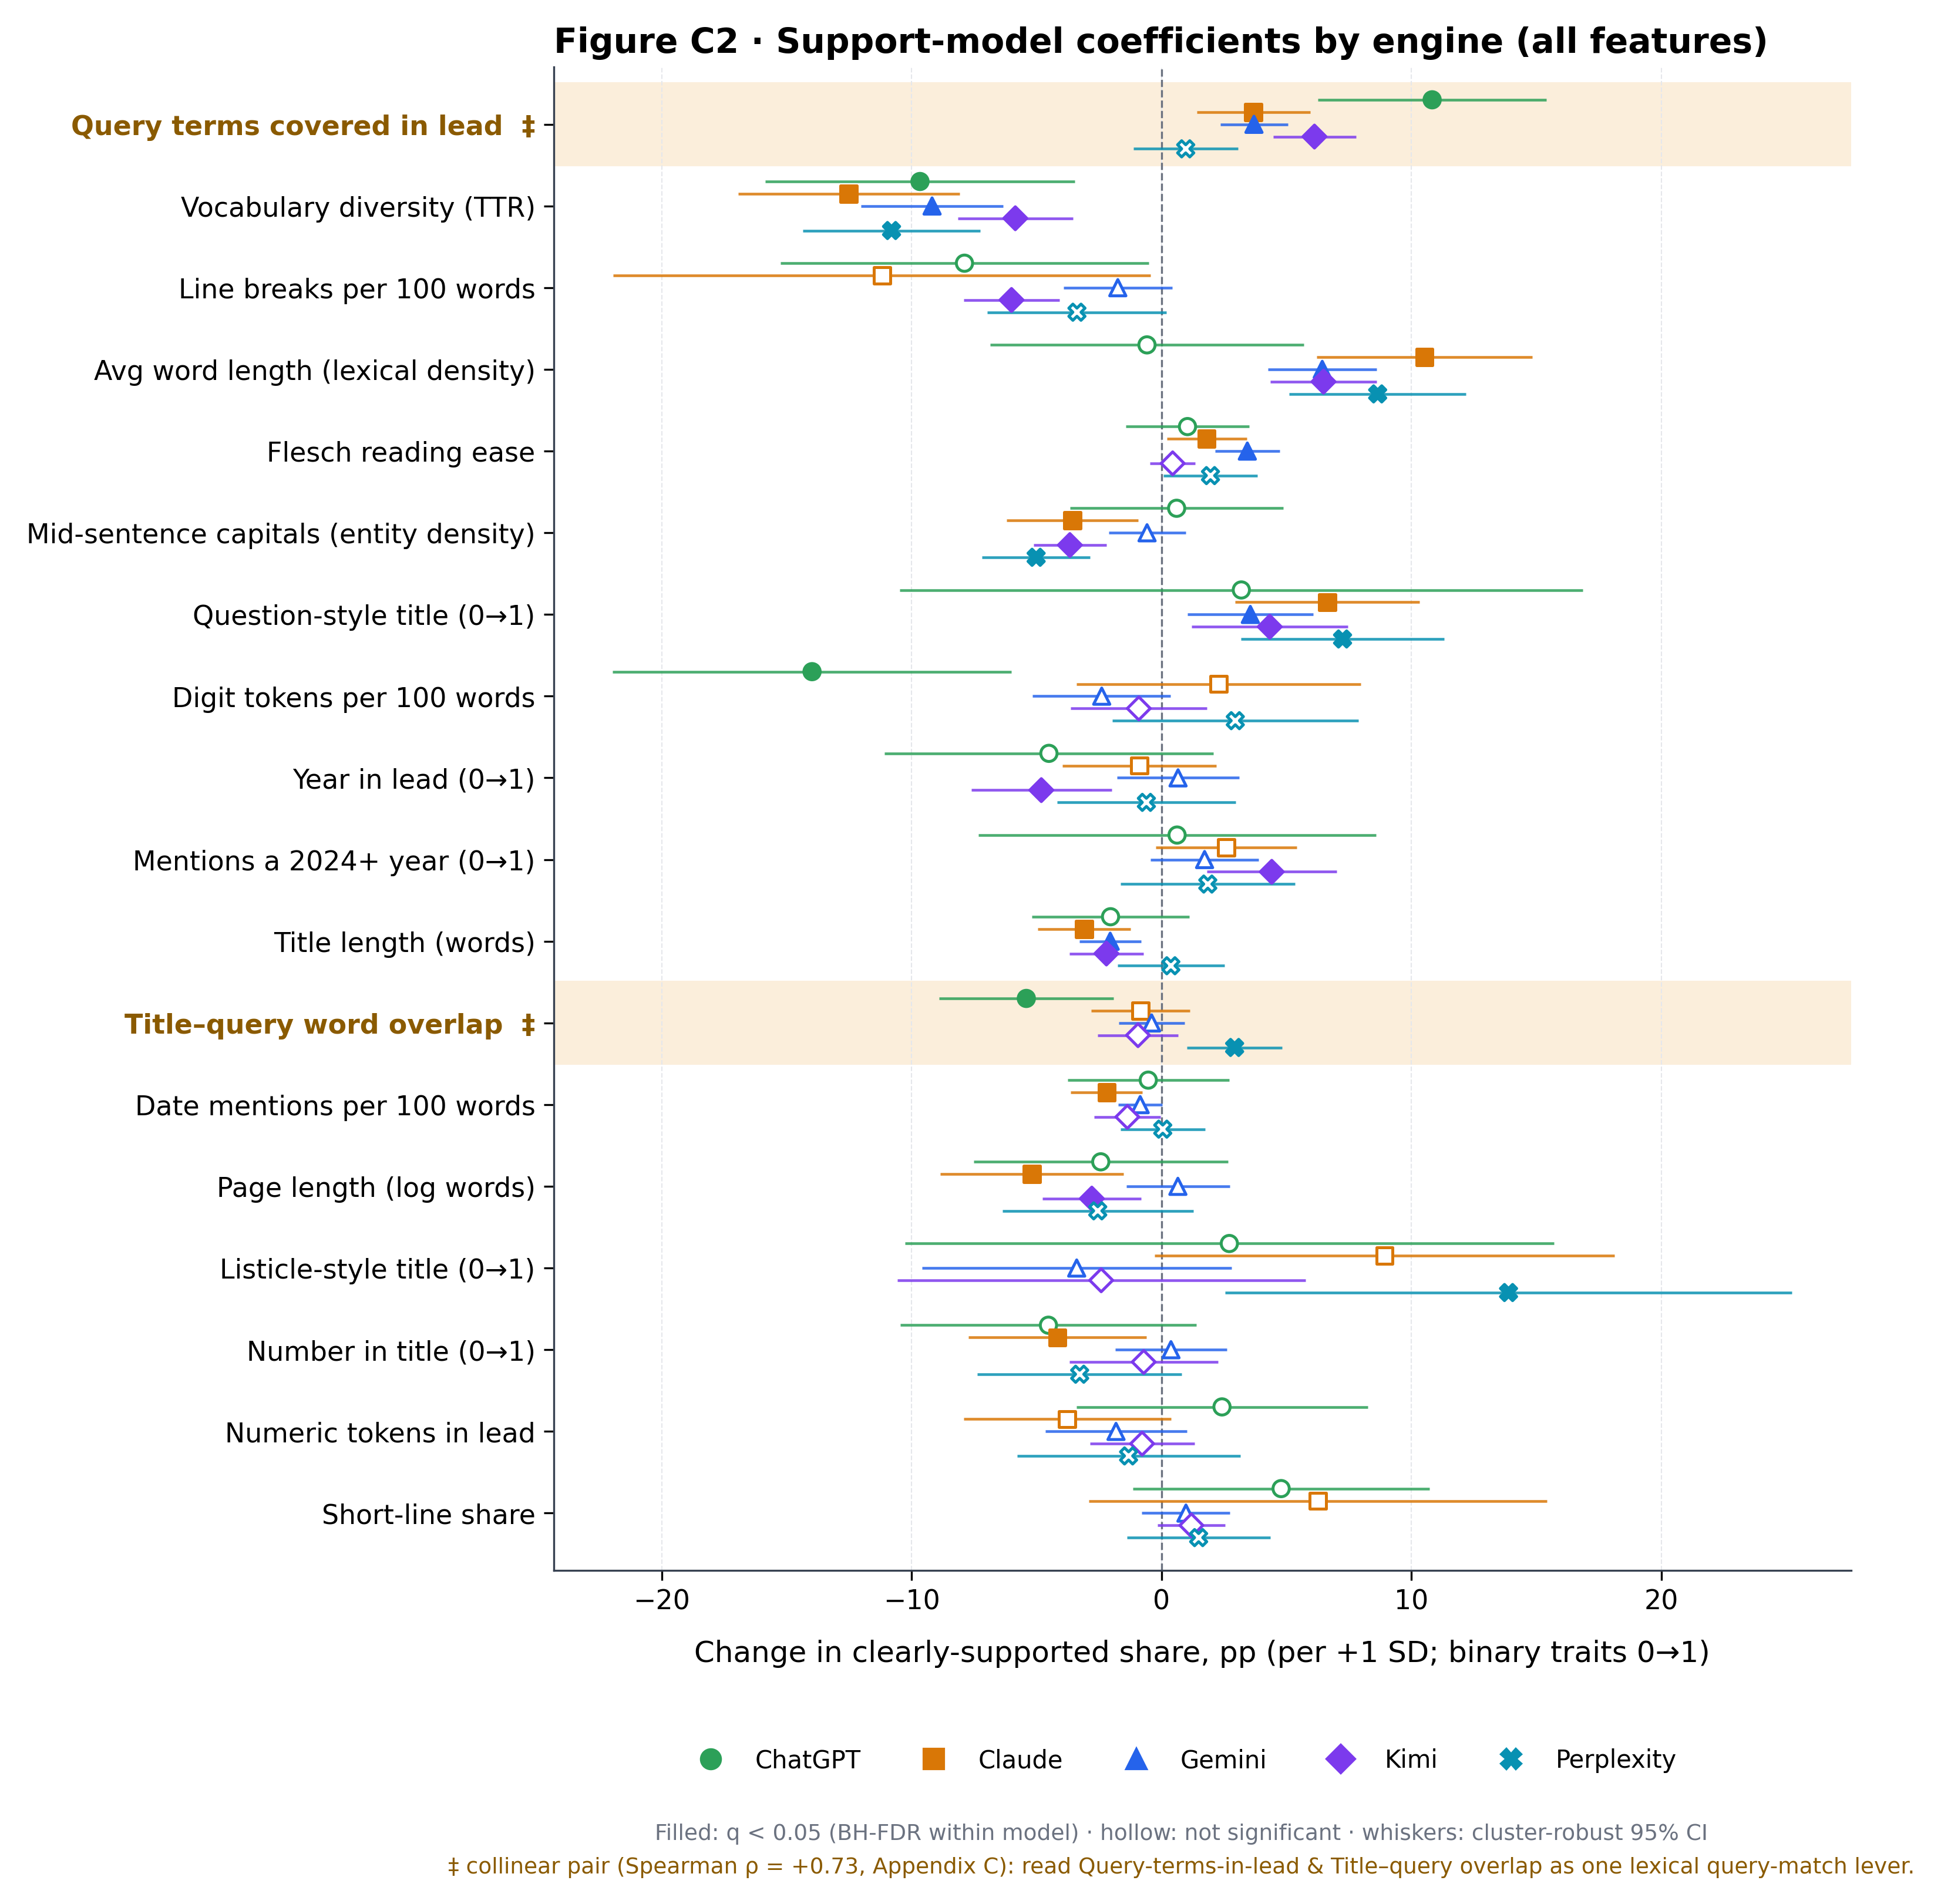

In [8]:
# Figure C2 · Support-model coefficients, per-engine forest (all features) — Figure-13 conventions.
#   Appendix companion to PF2/fig_pf_q2. Highlights the lexical query-match collinear pair (Spearman ρ=+0.73, Appendix C).
FIG_PARENT = os.path.join(ROOT, "figures/scaleup")
QM_PAIR = ["lead_query_coverage", "title_query_jaccard"]; HL, HLTXT = "#FBEEDB", "#8A5A00"

def _qm_ticklabels(ax, order):                                              # bold + ‡ on the two collinear rows
    ax.set_yticklabels([DISP[f] + ("  ‡" if f in QM_PAIR else "") for f in order])
    for lab, f in zip(ax.get_yticklabels(), order):
        if f in QM_PAIR: lab.set_fontweight("bold"); lab.set_color(HLTXT)

r = RES[(RES.outcome == "support") & (RES.engine.isin(ENGINE_ORDER))].copy()
order = r.groupby("feature").z.apply(lambda s: s.abs().max()).sort_values(ascending=False).index.tolist()
n = len(order); ybase = np.arange(n)[::-1]; ypos = dict(zip(order, ybase)); scale = 100.0
fig, ax = plt.subplots(figsize=(9.5, 0.46 * n + 2.8))
for f in QM_PAIR: ax.axhspan(ypos[f] - 0.5, ypos[f] + 0.5, color=HL, zorder=0)   # highlight collinear rows
offs = np.linspace(0.30, -0.30, len(ENGINE_ORDER))
for oi, eng in enumerate(ENGINE_ORDER):
    d = r[r.engine == eng].set_index("feature").reindex(order); y = ybase + offs[oi]; sig = d.q.values < 0.05
    ax.errorbar(d.beta.values * scale, y, xerr=1.96 * d.se.values * scale, fmt="none",
                ecolor=ENGINE_COLOURS[eng], elinewidth=1.1, capsize=0, alpha=0.85)
    ax.scatter(d.beta.values * scale, y, marker=ENGINE_MARKERS[eng], s=44, zorder=3,
               facecolors=np.where(sig, ENGINE_COLOURS[eng], "white"), edgecolors=ENGINE_COLOURS[eng], linewidths=1.2)
ax.axvline(0, color=COLOUR_NEUTRAL, linewidth=0.8, linestyle="--", zorder=1)
ax.set_yticks(ybase); ax.set_ylim(-0.7, n - 0.3); _qm_ticklabels(ax, order)
ax.set_xlabel("Change in clearly-supported share, pp (per +1 SD; binary traits 0→1)")
ax.set_title("Figure C2 · Support-model coefficients by engine (all features)", loc="left")
apply_style(ax); ax.grid(False); ax.xaxis.grid(True, color=COLOUR_GRID, linewidth=0.5, linestyle="--")
handles = [Line2D([], [], color=ENGINE_COLOURS[e], marker=ENGINE_MARKERS[e], linestyle="none",
                  markersize=8, label=ENGINE_LABELS[e]) for e in ENGINE_ORDER]
fig.legend(handles=handles, ncol=5, loc="lower center", bbox_to_anchor=(0.5, -0.005), frameon=False, fontsize=10)
fig.text(0.5, -0.028, "Filled: q < 0.05 (BH-FDR within model) · hollow: not significant · whiskers: cluster-robust 95% CI",
         ha="center", fontsize=9, color=COLOUR_NEUTRAL)
fig.text(0.5, -0.045, "‡ collinear pair (Spearman ρ = +0.73, Appendix C): read Query-terms-in-lead & Title–query overlap as one lexical query-match lever.",
         ha="center", fontsize=9, color=HLTXT)
savefig(fig, "fig_pf_C2_support_forest")                                    # canonical figures/scaleup/pagefeat/
for ext in ("png", "pdf"): fig.savefig(os.path.join(FIG_PARENT, f"fig_pf_C2_support_forest.{ext}"))   # requested target
print("also saved fig_pf_C2_support_forest -> figures/scaleup/"); plt.show()

saved fig_pf_C3_recitation_pooled


also saved fig_pf_C3_recitation_pooled -> figures/scaleup/
             feature  beta_pp     q  k
 title_query_jaccard     3.89 0.000  4
 lead_query_coverage     3.09 0.000  4
     title_len_words    -1.39 0.002  4
   title_is_question    -2.17 0.099  4
      dates_per_100w    -0.75 0.164  4
    short_line_share     1.47 0.321  4
     has_recent_year     1.11 0.407  4
lead_num_token_share    -1.10 0.430  4
       lead_has_year     0.93 0.430  4
            flesch_c     0.41 0.430  4
      title_listicle     2.44 0.469  4
    title_has_number     0.63 0.704  4
        avg_word_len    -0.48 0.704  4
      caps_mid_share     0.29 0.704  4
     digits_per_100w     0.44 0.786  4
            ttr_1000    -0.28 0.786  4
       log1p_n_words     0.18 0.798  4
   newlines_per_100w     0.24 0.798  4


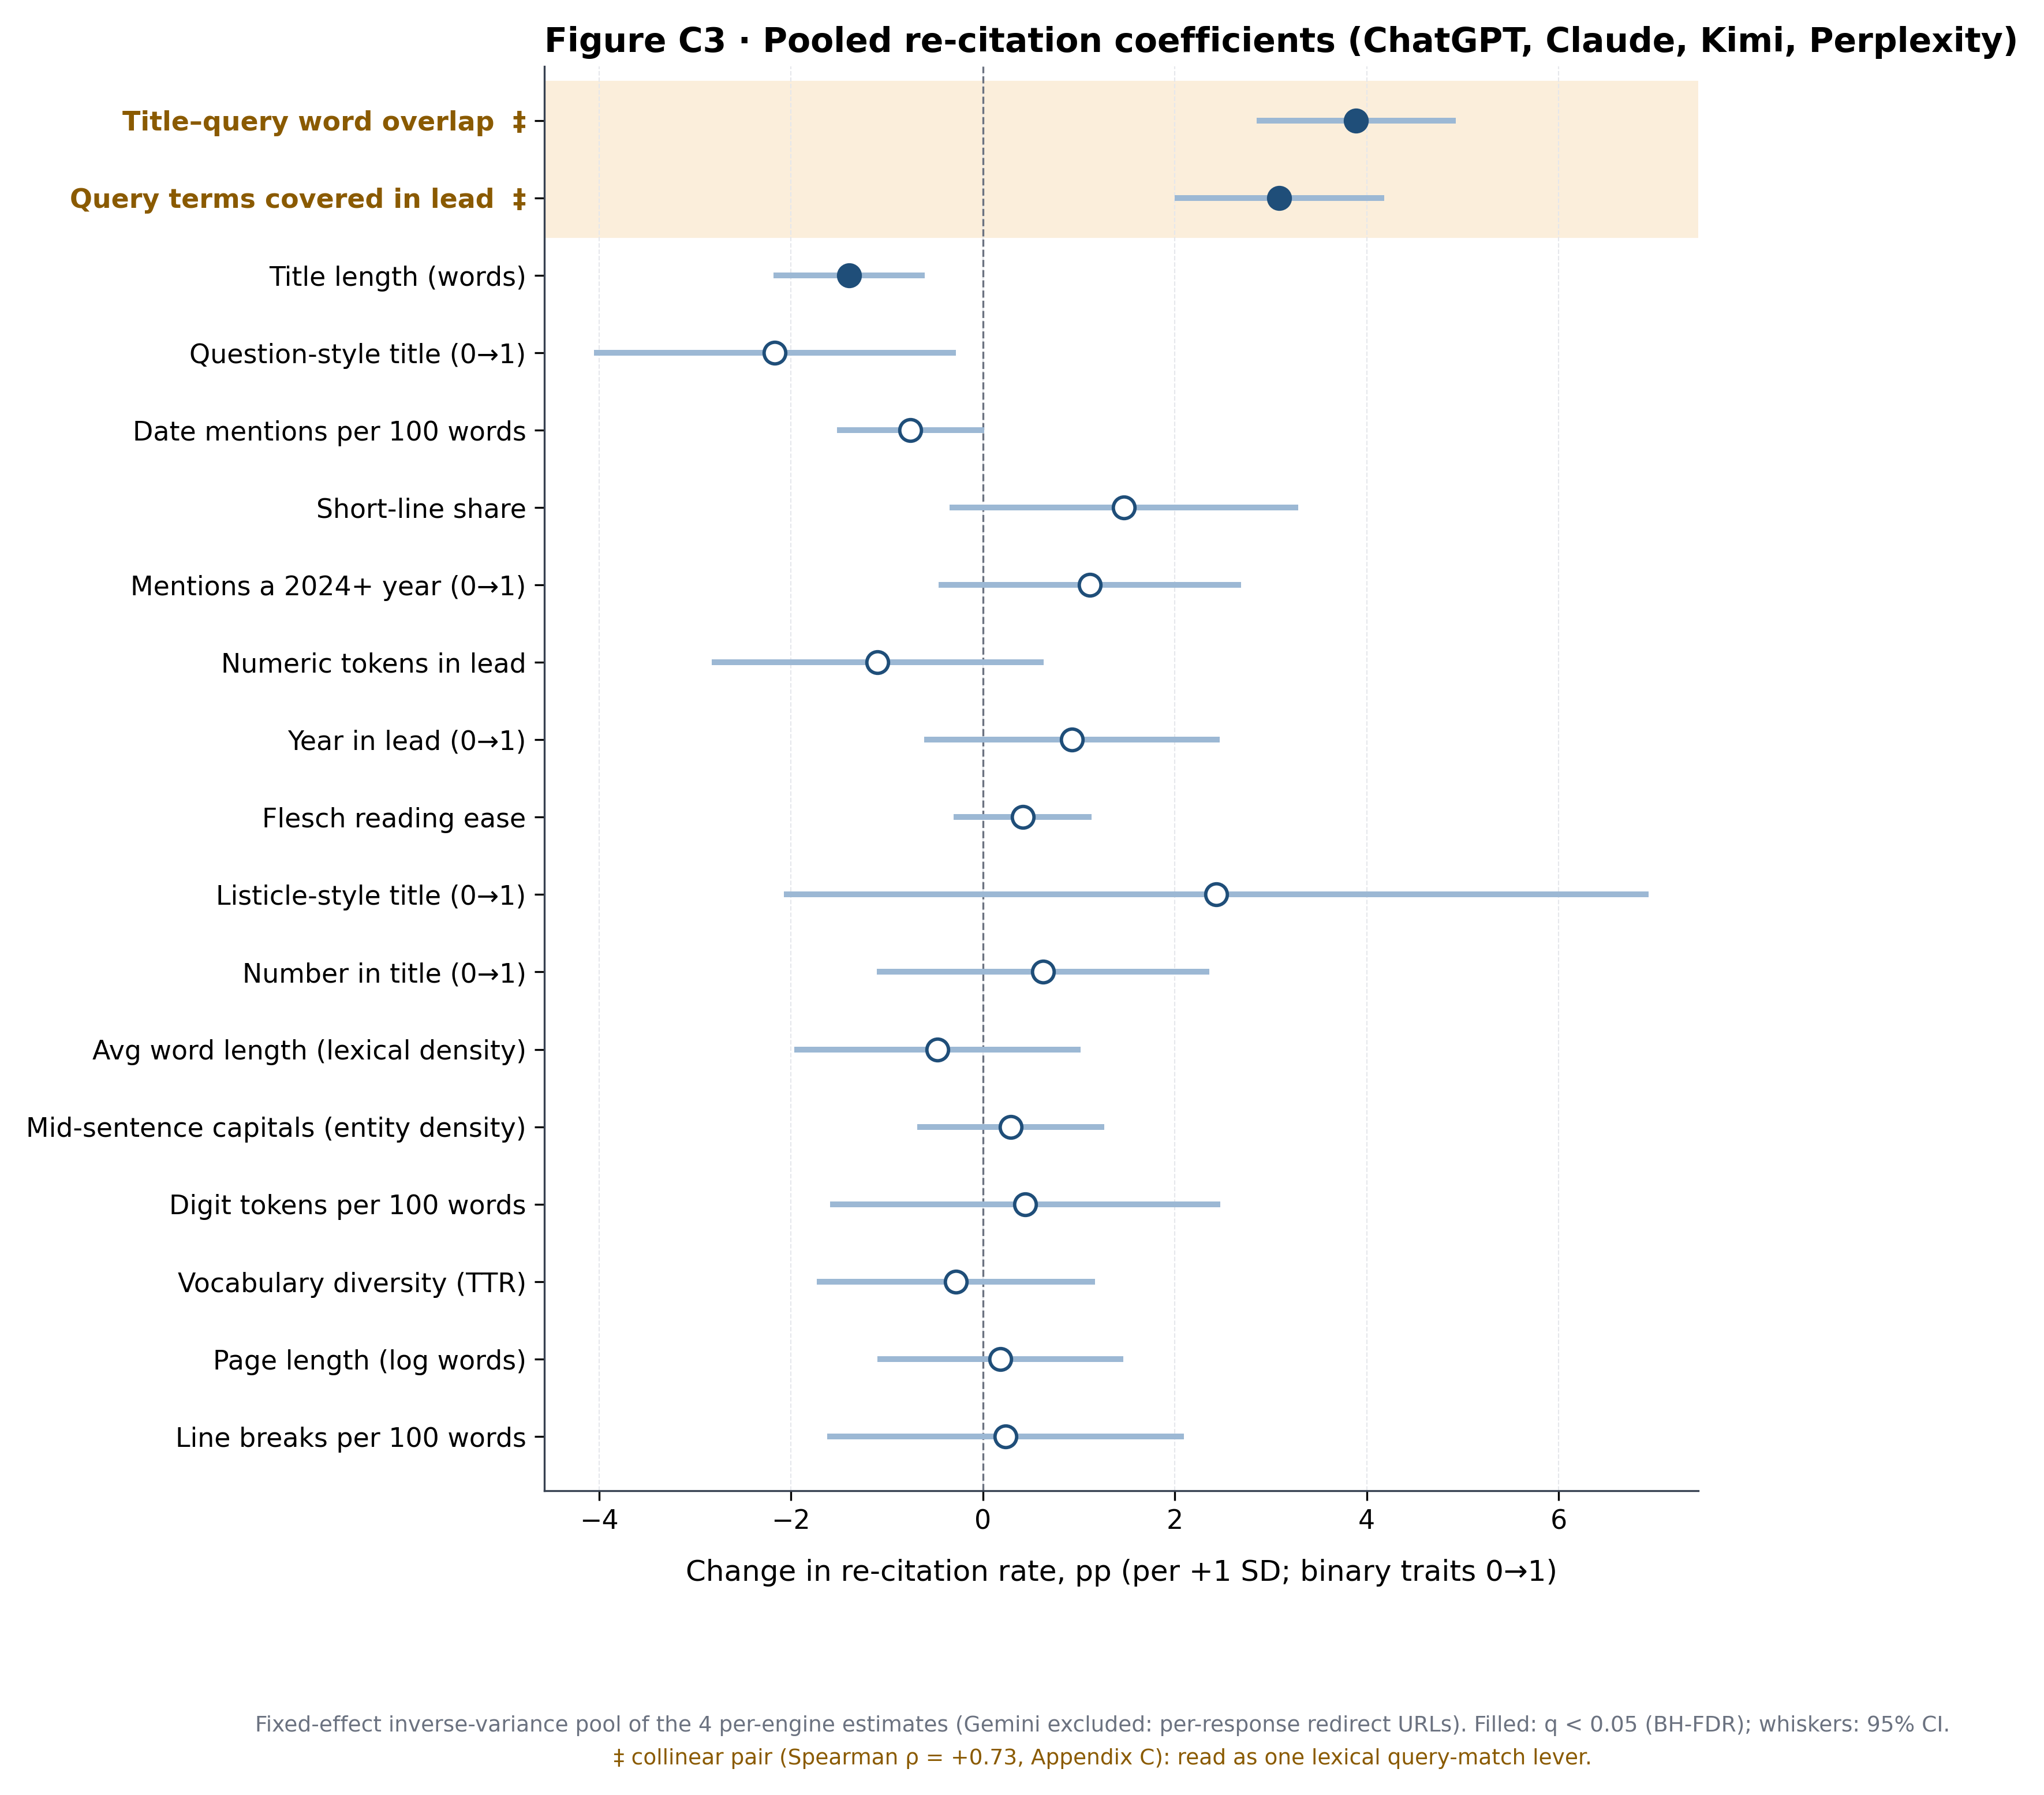

In [9]:
# Figure C3 · Pooled re-citation coefficients across ChatGPT/Claude/Kimi/Perplexity (Gemini excluded).
#   Fixed-effect inverse-variance pool of the 4 per-engine sticky estimates; one point per feature + 95% CI.
STK = RES[RES.outcome == "sticky"]                                          # ST model already excludes Gemini
_pool = []
for f, g in STK.groupby("feature"):
    w = 1.0 / g.se.values**2; b = float(np.sum(w * g.beta.values) / np.sum(w)); se = float(np.sqrt(1.0 / np.sum(w)))
    _pool.append(dict(feature=f, beta=b, se=se, z=b / se, p=float(2 * stats.norm.sf(abs(b / se))), k=len(g)))
POOL = pd.DataFrame(_pool); POOL["q"] = bh_fdr(POOL.p.values)
POOL = POOL.sort_values("z", key=lambda s: s.abs(), ascending=False).reset_index(drop=True)
order = POOL.feature.tolist(); n = len(order); ybase = np.arange(n)[::-1]; ypos = dict(zip(order, ybase))
fig, ax = plt.subplots(figsize=(8.6, 0.46 * n + 2.4))
for f in QM_PAIR: ax.axhspan(ypos[f] - 0.5, ypos[f] + 0.5, color=HL, zorder=0)   # highlight collinear rows
for _, row in POOL.iterrows():
    yy = ypos[row.feature]; b = row.beta * 100; lo = (row.beta - 1.96 * row.se) * 100; hi = (row.beta + 1.96 * row.se) * 100
    ax.plot([lo, hi], [yy, yy], color="#9CB8D4", linewidth=2.4, zorder=2)                       # 95% CI
    ax.plot(b, yy, "o", markersize=9, markerfacecolor=COLOUR_PRIMARY if row.q < 0.05 else "white",
            markeredgecolor=COLOUR_PRIMARY, markeredgewidth=1.4, zorder=3)                       # filled = q<0.05
ax.axvline(0, color=COLOUR_NEUTRAL, linewidth=0.8, linestyle="--", zorder=1)
ax.set_yticks(ybase); ax.set_ylim(-0.7, n - 0.3); _qm_ticklabels(ax, order)
ax.set_xlabel("Change in re-citation rate, pp (per +1 SD; binary traits 0→1)")
ax.set_title("Figure C3 · Pooled re-citation coefficients (ChatGPT, Claude, Kimi, Perplexity)", loc="left")
apply_style(ax); ax.grid(False); ax.xaxis.grid(True, color=COLOUR_GRID, linewidth=0.5, linestyle="--")
fig.text(0.5, -0.02, "Fixed-effect inverse-variance pool of the 4 per-engine estimates (Gemini excluded: per-response redirect URLs). "
         "Filled: q < 0.05 (BH-FDR); whiskers: 95% CI.", ha="center", fontsize=9, color=COLOUR_NEUTRAL)
fig.text(0.5, -0.038, "‡ collinear pair (Spearman ρ = +0.73, Appendix C): read as one lexical query-match lever.",
         ha="center", fontsize=9, color=HLTXT)
savefig(fig, "fig_pf_C3_recitation_pooled")                                 # canonical figures/scaleup/pagefeat/
for ext in ("png", "pdf"): fig.savefig(os.path.join(FIG_PARENT, f"fig_pf_C3_recitation_pooled.{ext}"))   # requested target
print("also saved fig_pf_C3_recitation_pooled -> figures/scaleup/")
print(POOL.assign(beta_pp=(POOL.beta * 100).round(2))[["feature", "beta_pp", "q", "k"]].round(3).to_string(index=False)); plt.show()